# LACT 恒星强度干涉：从天图、(uv) 测量到无相位成像

**目的。** 这是一条可执行、可审计的论文级闭环：输入天体亮度分布，生成理论复可见度和完整 (uv) 功率面；用 LACT 本地 ENU 阵列与地球自转生成每一对望远镜的 (u,v,w) 和几何时延；按 Hanbury Brown 灵敏度关系生成带不确定度的 (|V|^2)；最后仅用模拟观测值做正值、有限支撑、平滑正则的无相位图像重建。

## tl;dr

- 统一实现保留旧 v1 的多源模型、全阵列相干矩阵思想和不确定度加权重建，并吸收旧 v2 对飞秒光学相干、纳秒电子学及小时级积分必须分层处理的修正。
- notebook 同时计算仓库 7 镜验证阵列和历史 `layout_0803` 生产输入的 **TEL.1–TEL.32 实际模拟坐标**；不再使用理想化 grouped layout。
- 默认科学案例是 (m_{AB}=2)、分离 (0.20\,\mathrm{mas}) 的不等亮双星；重建器看不到真值相位，真值只在优化结束后用于平移/180°镜像歧义下的验证。
- 星等极限和角分辨率是**假设驱动的预测**，不是 LACT 已实测性能；结果表明确列出通光效率、NSB、电子带宽、观测时间和光谱复用数。

## 1. Context & Methods

对混沌（热）光，Siegert 关系给出

\[
g^{(2)}_{ij}(\tau)-1=\beta\,|\gamma_{ij}|^2\,|g^{(1)}(\tau)|^2,
\]

而 van Cittert–Zernike 定理将复相干度 \(\gamma(u,v)\) 与归一化源亮度天图的傅里叶变换相连。强度干涉直接测得的是 \(|\gamma|^2\)，不测傅里叶相位，因此图像存在绝对平移与 180°反演歧义。

长曝光、shot-noise 主导时，本 notebook 使用与 Hanbury Brown、Le Bohec–Holder、Rou 等工作一致的二阶相关近似：

\[
\mathrm{SNR}_{ij}=\frac{r_{\star,i}r_{\star,j}}
{\sqrt{r_{\mathrm{tot},i}r_{\mathrm{tot},j}}\,\Delta\nu}
|\gamma_{ij}|^2\sqrt{\frac{\Delta f\,T}{2}}\,\frac{1}{F_{\rm EN}},
\]

等口径时化为代码中的 `unit_visibility_snr × |V|²`。背景进入总 shot noise，但不产生跨镜恒星相关。观测模拟不裁剪负的 \(|V|^2\) 估计，避免低 SNR 下的正偏差。

### 关键参考

1. Le Bohec & Holder (2006), *Optical Intensity Interferometry with Atmospheric Cherenkov Telescope Arrays*, DOI: [10.1086/507030](https://doi.org/10.1086/507030).
2. Dravins et al. (2012), *Stellar Intensity Interferometry: Prospects for sub-milliarcsecond optical imaging*, [arXiv:1207.0808](https://arxiv.org/abs/1207.0808).
3. Nuñez et al. (2012), *Imaging sub-milliarcsecond stellar features...*, [arXiv:1205.5743](https://arxiv.org/abs/1205.5743).
4. Rou et al. (2013), *Monte-Carlo simulation of stellar intensity interferometry*, [arXiv:1303.4023](https://arxiv.org/abs/1303.4023).
5. Zhang et al. (2025), LACT 32 镜/6 m 与 grouped layout 间距研究, [arXiv:2409.14382](https://arxiv.org/abs/2409.14382).
6. H.E.S.S.、MAGIC、VERITAS 连续读出实现：[arXiv:2312.08015](https://arxiv.org/abs/2312.08015)、[arXiv:2402.04755](https://arxiv.org/abs/2402.04755)、[arXiv:1908.03095](https://arxiv.org/abs/1908.03095).

### 1.1 v1/v2 功能继承矩阵

统一版是以最新 `main` 为底座的科学能力整合，不是把两个旧分支逐文件相加。下表明确区分已经落地和仍需补齐的部分。

| 能力 | 旧 v1 | 旧 v2 | 统一版状态 |
|---|---|---|---|
| 双星/均匀圆盘/点源复可见度 | 完整 | 仅均匀圆盘为主 | **完整**；点源由零直径圆盘表示，双星进入全部基线 |
| 肢暗圆盘及更一般源模型库 | 有 | 无 | **部分**；当前论文 notebook 尚未暴露肢暗参数 |
| 全阵列所有望远镜对 | N 镜相干矩阵 | 主要为两镜 | **完整到逐基线层**；32镜496对，但未另存显式32×32矩阵 |
| 地球自转与站点纬度 | 有 | ENU公式缺纬度 | **完整且已修正** topocentric ENU `(u,v,w)` |
| 飞秒相干—纳秒波形—小时积分分层 | 较弱 | 核心优势 | **完整** |
| SPE、NSB、恢复、电子噪声、ADC短波形 | 简化 | 较完整但多为假设 | **增强整合**；使用main实测SPE/NSB/微单元，ADC仍为工程假设 |
| 分通道/分光探测器的六路相关器 | 无 | 有四通道示例 | **尚未完整继承**；当前科学量为每镜合并后的像素相关 |
| 几何、线缆与时钟延迟 | 几何为主 | 几何+线缆假设 | **部分**；几何时延完整，0.2 ns残差示意，未加入实测时钟漂移 |
| 长曝光HBT灵敏度与NSB误差 | 有 | 核心优势 | **完整并扩展**到多夜、NSB、电子学受控情景 |
| 无相位非参数图像重建 | 核心优势 | 无 | **完整**；正值、有限支撑、平滑正则、多起点、误差加权 |
| 旧版专用C++恒星干涉入口 | 有 | 有 | **未原样保留**；统一研究入口为Python模块和可执行notebook，C++ main只补入微单元恢复 |

因此当前版本已经形成“模型→UV→短波形电子学→长曝光测量→无相位重建”的完整论文闭环；但若目标是复现 v2 的真实多通道相关器硬件，或系统研究 v1 的肢暗恒星，还需要后续模块。

In [1]:
from __future__ import annotations

import math
import os
import platform
import sys
from dataclasses import dataclass, asdict, replace
from pathlib import Path
from itertools import combinations

import matplotlib
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.optimize import brentq, least_squares
from scipy.ndimage import gaussian_filter
from scipy.special import j1
from scipy.stats import beta
from IPython.display import display, Markdown

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "python" / "sii_reconstruction.py").exists():
    REPO_ROOT = Path.cwd().resolve().parent
assert (REPO_ROOT / "python" / "sii_reconstruction.py").exists(), REPO_ROOT
sys.path.insert(0, str(REPO_ROOT / "python"))
OUTPUT_DIR = REPO_ROOT / "run_logs" / "sii_paper_notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(20260823)
MAS_TO_RAD = np.deg2rad(1.0 / 3_600_000.0)
RAD_TO_MAS = 1.0 / MAS_TO_RAD
C = 299_792_458.0
H_PLANCK = 6.626_070_15e-34
SIDEREAL_DAY_S = 86_164.0905
JY = 1e-26

BLUE = "#2463A8"
ORANGE = "#D97A2B"
GOLD = "#B9972E"
INK = "#25313C"
GREY = "#98A2AD"
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "semibold",
    "axes.labelcolor": INK,
    "text.color": INK,
    "font.size": 10,
})

print({
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "repo": str(REPO_ROOT),
    "output": str(OUTPUT_DIR),
})

{'python': '3.13.13', 'numpy': '2.4.4', 'scipy': '1.17.1', 'matplotlib': '3.10.9', 'repo': 'E:\\LACT_pylast2\\lact_sii_unified', 'output': 'E:\\LACT_pylast2\\lact_sii_unified\\run_logs\\sii_paper_notebook'}


### 1.2 可见的参数和假设

默认采用 400 nm、2 nm 光学带宽、200 MHz 电子相关带宽、主程序给出的 24.576860 m² 遮挡后有效面积、20% 总通光/探测效率和 70.527 MHz/pixel 暗天 NSB 预测。实测 SPE 电荷样本给出 RMS 因子 1.016142。站点纬度使用仓库验证配置的 (29.36^\circ)。10 ns 微单元恢复时间、ADC 和电子噪声是待标定工程假设，下面单独标识。

In [2]:
@dataclass(frozen=True)
class Instrument:
    wavelength_nm: float = 400.0
    optical_width_nm: float = 2.0
    telescope_diameter_m: float = 6.0
    effective_area_m2: float = 24.576860
    throughput: float = 0.20
    electronics_bandwidth_hz: float = 200e6
    adc_sample_rate_hz: float = 625e6
    detected_nsb_rate_hz: float = 70.527e6
    excess_noise_factor: float = 1.016142
    microcells_per_pixel: int = 270336
    microcell_recovery_time_ns: float = 10.0
    electronic_noise_rms_mv: float = 0.35
    adc_bits: int = 8
    adc_full_scale_mv: float = 200.0
    polarization_factor: float = 0.5
    spectral_shape_factor: float = 0.842
    calibration_floor_visibility2: float = 0.015
    telescope_gain_calibration_rms: float = 0.010
    per_night_gain_rms: float = 0.005
    baseline_zero_point_rms: float = 0.005
    residual_timing_rms_ns: float = 0.20
    transparency_fractional_rms: float = 0.03
    nsb_fractional_rms: float = 0.10
    site_lat_deg: float = 29.36
    source_dec_deg: float = 22.0
    observing_hours: float = 6.0
    segment_s: float = 1200.0
    source_ab_magnitude: float = 2.0

    @property
    def wavelength_m(self): return self.wavelength_nm * 1e-9
    @property
    def optical_width_m(self): return self.optical_width_nm * 1e-9
    @property
    def collecting_area_m2(self): return self.effective_area_m2
    @property
    def optical_bandwidth_hz(self):
        return C * self.optical_width_m / self.wavelength_m**2
    @property
    def sample_width_s(self): return 1.0 / self.adc_sample_rate_hz
    @property
    def coherence_area_s(self):
        return (self.polarization_factor * self.spectral_shape_factor
                * self.wavelength_m**2 / (C * self.optical_width_m))

@dataclass(frozen=True)
class BinarySource:
    separation_mas: float = 0.20
    position_angle_deg: float = 35.0  # east of north
    flux_ratio_secondary_to_primary: float = 0.55
    primary_diameter_mas: float = 0.060
    secondary_diameter_mas: float = 0.040

INST = Instrument()
SOURCE = BinarySource()
display(pd.DataFrame([asdict(INST)]).T.rename(columns={0: "value"}))
display(pd.DataFrame([asdict(SOURCE)]).T.rename(columns={0: "value"}))

,value
wavelength_nm,4.000000e+02
optical_width_nm,2.000000e+00
telescope_diameter_m,6.000000e+00
effective_area_m2,2.457686e+01
throughput,2.000000e-01
electronics_bandwidth_hz,2.000000e+08
adc_sample_rate_hz,6.250000e+08
detected_nsb_rate_hz,7.052700e+07
excess_noise_factor,1.016142e+00
microcells_per_pixel,2.703360e+05


,value
separation_mas,0.20
position_angle_deg,35.00
flux_ratio_secondary_to_primary,0.55
primary_diameter_mas,0.06
secondary_diameter_mas,0.04


In [3]:
parameter_status = pd.DataFrame([
    ["32 telescope coordinates", "available", "layout_0803 run-card export", "used directly"],
    ["mirror area after obstruction", "available", "main NSB model: 24.576860 m²", "used directly"],
    ["mirror/filter/PDE curves", "available", "main configs/efficiency", "collapsed to 20% reference throughput"],
    ["measured SPE template", "available", "537 clean pulses; 84.0349557 mV ns/PE", "used in short waveform"],
    ["SPE charge dispersion", "available", "537 empirical factors; RMS factor 1.016142", "sampled per PE and used in long-exposure ENF"],
    ["dark-sky NSB", "model estimate", "70.527 MHz/pixel under documented SkyCalc conditions", "scenario input"],
    ["S17351 microcell geometry", "available", "8 channels, 270336 cells/pixel, 25 µm pitch", "used directly"],
    ["S17351 recovery time", "not publicly specified", "10 ns provisional; Hamamatsu generic scale ~15 ns", "scan 1/10/30 ns"],
    ["ADC sample rate/full scale/bits", "engineering assumption", "625 MS/s, 200 mV, 8 bit from old v2", "short waveform plus approximate long-exposure penalty"],
    ["electronic noise", "engineering assumption", "0.35 mV RMS from old v2", "short waveform plus approximate long-exposure penalty"],
    ["electronics correlation bandwidth", "engineering assumption", "200 MHz", "sensitivity scenario"],
    ["crosstalk/afterpulse/dark rate", "missing", "requires temperature/overvoltage calibration", "not enabled"],
    ["on-axis optical arrival-time spread", "ray-trace derived", "590239 accepted rays; compact 54-facet mixture", "used in short waveform and long-exposure transfer"],
    ["clock drift/residual delay", "engineering assumption", "0.2 ns RMS per telescope; requires timing calibration runs", "shared telescope nuisance"],
    ["gain/NSB/transparency stability", "engineering assumption", "1% static gain, 0.5% nightly gain, 10% NSB and 3% transparency RMS", "shared telescope sensitivity scan"],
    ["narrow-band filter angular response", "missing", "2 nm top-hat approximation", "systematic caveat"],
], columns=["parameter", "status", "source_or_value", "treatment"])
display(parameter_status)
parameter_status.to_csv(OUTPUT_DIR / "parameter_availability.csv", index=False)

,parameter,status,source_or_value,treatment
0,32 telescope coordinates,available,layout_0803 run-card export,used directly
1,mirror area after obstruction,available,main NSB model: 24.576860 m²,used directly
2,mirror/filter/PDE curves,available,main configs/efficiency,collapsed to 20% reference throughput
3,measured SPE template,available,537 clean pulses; 84.0349557 mV ns/PE,used in short waveform
4,SPE charge dispersion,available,537 empirical factors; RMS factor 1.016142,sampled per PE and used in long-exposure ENF
5,dark-sky NSB,model estimate,70.527 MHz/pixel under documented SkyCalc cond...,scenario input
6,S17351 microcell geometry,available,"8 channels, 270336 cells/pixel, 25 µm pitch",used directly
7,S17351 recovery time,not publicly specified,10 ns provisional; Hamamatsu generic scale ~15 ns,scan 1/10/30 ns
8,ADC sample rate/full scale/bits,engineering assumption,"625 MS/s, 200 mV, 8 bit from old v2",short waveform plus approximate long-exposure ...
9,electronic noise,engineering assumption,0.35 mV RMS from old v2,short waveform plus approximate long-exposure ...


## 2. Array data: 仓库阵列与 layout_0803 实际 32 镜坐标

32 镜数据来自本工作区历史运行日志 `main_userv2_comparison_20260820/main_corsika.log:248–279`，其完整记录了 `layout_0803` 的 `TELESCOPE ... TEL.1`至`TEL.32`卡。同一坐标块在 2026-08-15至21 的 8 份独立本地运行日志中逐行一致（规范化后 SHA-256 前缀 `bc7f1cfa970b2d58`）。日志第 59–60 行声明输入系为 `corsika_nwu_relative`。CORSIKA 卡坐标单位为 cm，转为本 notebook 的 ENU 系时使用

\[
E=-y_{\rm west}/100,\qquad N=x_{\rm north}/100,\qquad U=z_{\rm up}/100.
\]

导出的 CSV 同时保留原始 NWU 列、ENU 列、CORSIKA 的 1-based 镜号和 LACTsim 的 0-based 索引，以便审计。

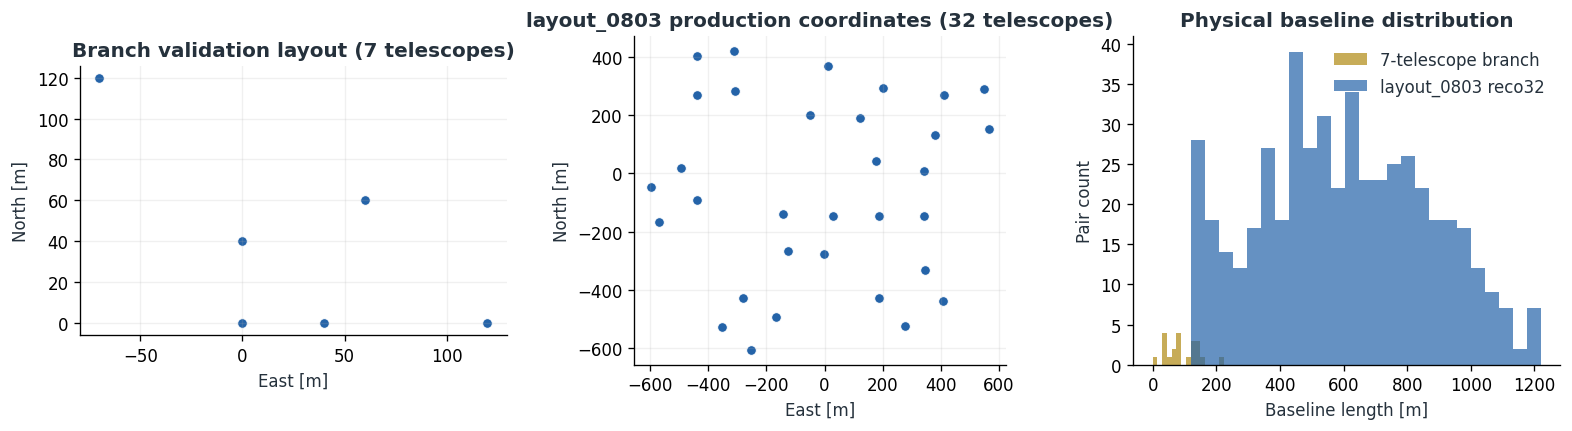

,layout,telescopes,pairs,min_nonzero_baseline_m,max_baseline_m
0,branch_7,7,21,40.000,224.722
1,layout_0803_reco32,32,496,121.005,1219.210


In [4]:
def load_branch_layout(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path)
    return frame.rename(columns={
        "position_x_m": "east_m",
        "position_y_m": "north_m",
        "position_z_m": "up_m",
    })[["telescope_id", "name", "east_m", "north_m", "up_m"]]

def load_layout_0803_reco32(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path)
    assert len(frame) == 32
    assert frame.telescope_id.tolist() == list(range(1, 33))
    assert frame.lactsim_index.tolist() == list(range(32))
    assert frame.telescope_id.is_unique and frame.lactsim_index.is_unique
    assert np.allclose(frame.east_m, -frame.corsika_west_cm / 100.0)
    assert np.allclose(frame.north_m, frame.corsika_north_cm / 100.0)
    assert np.allclose(frame.up_m, frame.corsika_up_cm / 100.0)
    return frame

def baseline_table(layout: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for i, j in combinations(range(len(layout)), 2):
        a, b = layout.iloc[i], layout.iloc[j]
        vec = b[["east_m", "north_m", "up_m"]].to_numpy(float) - a[["east_m", "north_m", "up_m"]].to_numpy(float)
        rows.append({
            "i": int(a.telescope_id), "j": int(b.telescope_id),
            "name_i": a["name"], "name_j": b["name"],
            "east_m": vec[0], "north_m": vec[1], "up_m": vec[2],
            "baseline_m": np.linalg.norm(vec),
        })
    return pd.DataFrame(rows)

BRANCH_LAYOUT = load_branch_layout(REPO_ROOT / "configs" / "arrays" / "star_interferometry_v2_array.csv")
LACT32 = load_layout_0803_reco32(
    REPO_ROOT / "configs" / "arrays" / "layout_0803_reco32_coordinates.csv"
)
branch_baselines = baseline_table(BRANCH_LAYOUT)
lact_baselines = baseline_table(LACT32)

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.7))
for axis, layout, title in [
    (axes[0], BRANCH_LAYOUT, "Branch validation layout (7 telescopes)"),
    (axes[1], LACT32, "layout_0803 production coordinates (32 telescopes)"),
]:
    axis.scatter(layout.east_m, layout.north_m, s=34, color=BLUE, edgecolor="white", linewidth=0.6)
    axis.set(title=title, xlabel="East [m]", ylabel="North [m]")
    axis.set_aspect("equal", adjustable="box")
    axis.grid(alpha=0.18)
axes[2].hist(branch_baselines.baseline_m, bins=15, alpha=0.8, color=GOLD, label="7-telescope branch")
axes[2].hist(lact_baselines.baseline_m, bins=25, alpha=0.70, color=BLUE, label="layout_0803 reco32")
axes[2].set(title="Physical baseline distribution", xlabel="Baseline length [m]", ylabel="Pair count")
axes[2].legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "array_layouts_and_baselines.png", bbox_inches="tight")
plt.show()

layout_summary = pd.DataFrame([
    {"layout": "branch_7", "telescopes": len(BRANCH_LAYOUT), "pairs": len(branch_baselines),
     "min_nonzero_baseline_m": branch_baselines.loc[branch_baselines.baseline_m > 0, "baseline_m"].min(),
     "max_baseline_m": branch_baselines.baseline_m.max()},
    {"layout": "layout_0803_reco32", "telescopes": len(LACT32), "pairs": len(lact_baselines),
     "min_nonzero_baseline_m": lact_baselines.loc[lact_baselines.baseline_m > 0, "baseline_m"].min(),
     "max_baseline_m": lact_baselines.baseline_m.max()},
])
display(layout_summary.round(3))
layout_summary.to_csv(OUTPUT_DIR / "array_layout_summary.csv", index=False)

## 3. Data: 理论源天图与完整理论 (uv) 图

双星的两颗分量均为均匀圆盘。单个角直径为 \(\theta\) 的圆盘复可见度为

\[
V_{\rm UD}(q)=\frac{2J_1(\pi\theta q)}{\pi\theta q},\quad q=\sqrt{u^2+v^2}.
\]

两分量带上各自位置的傅里叶相位后按流量相加。天图和公式由同一参数对象生成，避免“画的源”和“模拟的可见度”不一致。

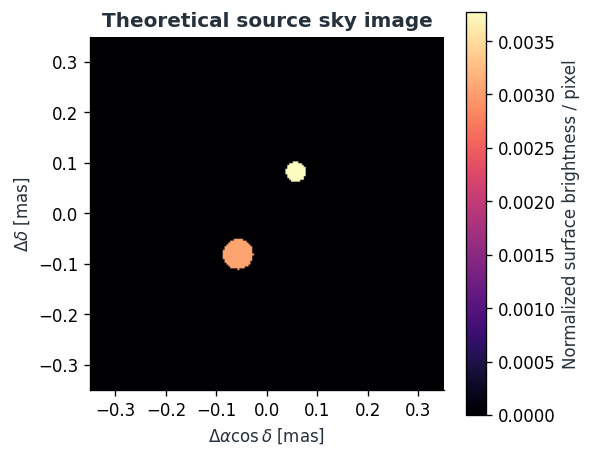

In [5]:
def uniform_disk_visibility(q_lambda, diameter_mas):
    x = np.pi * diameter_mas * MAS_TO_RAD * np.asarray(q_lambda)
    out = np.ones_like(x, dtype=float)
    mask = np.abs(x) > 1e-12
    out[mask] = 2.0 * j1(x[mask]) / x[mask]
    return out

def binary_offsets_rad(source=SOURCE):
    pa = np.deg2rad(source.position_angle_deg)
    dx = 0.5 * source.separation_mas * np.sin(pa) * MAS_TO_RAD
    dy = 0.5 * source.separation_mas * np.cos(pa) * MAS_TO_RAD
    return (-dx, -dy), (dx, dy)

def binary_visibility(u_lambda, v_lambda, source=SOURCE):
    u = np.asarray(u_lambda, dtype=float)
    v = np.asarray(v_lambda, dtype=float)
    q = np.hypot(u, v)
    (x1, y1), (x2, y2) = binary_offsets_rad(source)
    primary = uniform_disk_visibility(q, source.primary_diameter_mas) * np.exp(-2j * np.pi * (u*x1 + v*y1))
    secondary = uniform_disk_visibility(q, source.secondary_diameter_mas) * np.exp(-2j * np.pi * (u*x2 + v*y2))
    ratio = source.flux_ratio_secondary_to_primary
    return (primary + ratio * secondary) / (1.0 + ratio)

def render_binary_sky(source=SOURCE, fov_mas=0.70, pixels=192):
    theta = np.linspace(-fov_mas/2, fov_mas/2, pixels)
    xx, yy = np.meshgrid(theta, theta)
    (x1, y1), (x2, y2) = binary_offsets_rad(source)
    x1, y1, x2, y2 = np.array([x1, y1, x2, y2]) * RAD_TO_MAS
    image = ((xx-x1)**2 + (yy-y1)**2 <= (source.primary_diameter_mas/2)**2).astype(float)
    component2 = ((xx-x2)**2 + (yy-y2)**2 <= (source.secondary_diameter_mas/2)**2).astype(float)
    if component2.sum() > 0:
        component2 *= source.flux_ratio_secondary_to_primary * image.sum() / component2.sum()
    image += component2
    image /= image.sum()
    return theta, image

theta_sky, sky_image = render_binary_sky()
extent = [theta_sky[0], theta_sky[-1], theta_sky[0], theta_sky[-1]]
fig, axis = plt.subplots(figsize=(5.0, 4.2))
artist = axis.imshow(sky_image, origin="lower", extent=extent, cmap="magma")
axis.set(title="Theoretical source sky image", xlabel=r"$\Delta\alpha\cos\delta$ [mas]", ylabel=r"$\Delta\delta$ [mas]")
axis.set_aspect("equal")
fig.colorbar(artist, ax=axis, label="Normalized surface brightness / pixel")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "theoretical_source_sky.png", bbox_inches="tight")
plt.show()

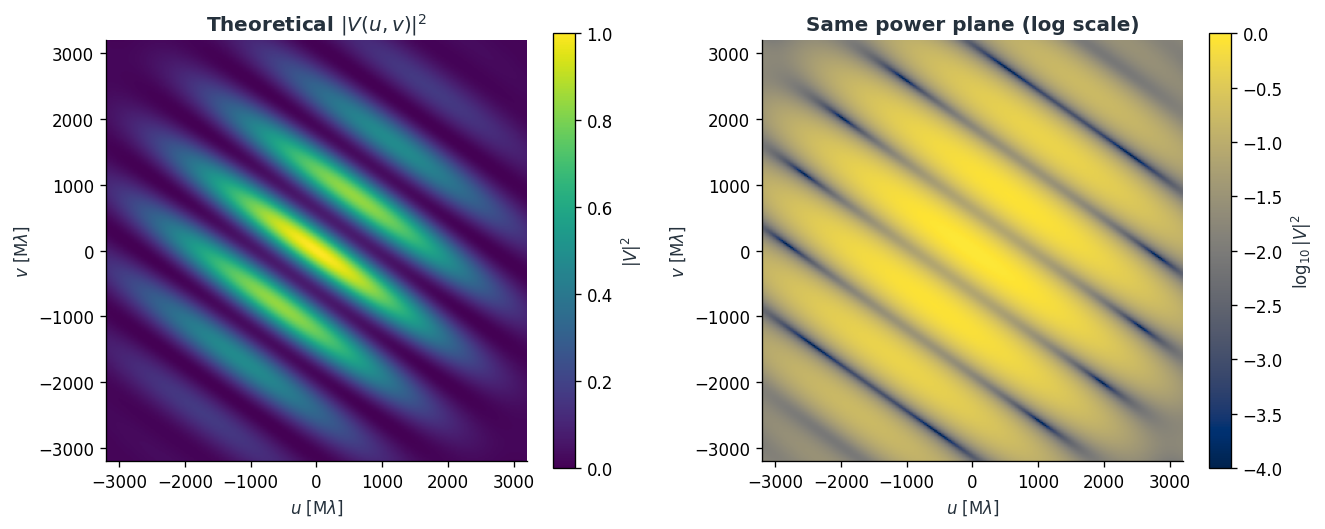

In [6]:
bmax_m = lact_baselines.baseline_m.max()
uv_limit = 1.05 * bmax_m / INST.wavelength_m
uv_axis = np.linspace(-uv_limit, uv_limit, 301)
uu, vv = np.meshgrid(uv_axis, uv_axis)
theory_power = np.abs(binary_visibility(uu, vv))**2

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.4))
im0 = axes[0].imshow(theory_power, origin="lower",
                     extent=np.array([-uv_limit, uv_limit, -uv_limit, uv_limit])/1e6,
                     cmap="viridis", vmin=0, vmax=1)
axes[0].set(title=r"Theoretical $|V(u,v)|^2$", xlabel=r"$u$ [M$\lambda$]", ylabel=r"$v$ [M$\lambda$]")
axes[0].set_aspect("equal")
fig.colorbar(im0, ax=axes[0], label=r"$|V|^2$")
im1 = axes[1].imshow(np.log10(np.clip(theory_power, 1e-4, 1)), origin="lower",
                     extent=np.array([-uv_limit, uv_limit, -uv_limit, uv_limit])/1e6,
                     cmap="cividis", vmin=-4, vmax=0)
axes[1].set(title="Same power plane (log scale)", xlabel=r"$u$ [M$\lambda$]", ylabel=r"$v$ [M$\lambda$]")
axes[1].set_aspect("equal")
fig.colorbar(im1, ax=axes[1], label=r"$\log_{10}|V|^2$")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "theoretical_uv_power.png", bbox_inches="tight")
plt.show()

assert np.isclose(abs(binary_visibility(0.0, 0.0))**2, 1.0, atol=1e-12)
assert np.allclose(theory_power, theory_power[::-1, ::-1], atol=2e-12)

## 4. 两台望远镜之间到底怎么算

对望远镜 (i,j)，先在本地 ENU 坐标中作基线

\[
\mathbf B_{ij}=\mathbf r_j-\mathbf r_i.
\]

给定站点纬度 \(\phi\)、源赤纬 \(\delta\) 和时角 \(H\)，源方向在 ENU 中为

\[
\hat s=(\cos\delta\sin H,\;\sin\delta\cos\phi-\cos\delta\cos H\sin\phi,\;
\sin\delta\sin\phi+\cos\delta\cos H\cos\phi).
\]

再定义天球东向 \(\hat u\propto \hat z\times\hat s\)、天球北向 \(\hat v=\hat s\times\hat u\)，得到

\[
(u,v,w)=(\mathbf B\cdot\hat u,\mathbf B\cdot\hat v,\mathbf B\cdot\hat s),
\quad \tau_g=w/c.
\]

这一步必须包含站点纬度；直接把本地 ENU 代入不含纬度的地固坐标矩阵会得到错误的轨迹。

,value
telescope_i,TEL.12
telescope_j,TEL.26
B_E_m,-903.451
B_N_m,-818.687
B_U_m,0.0
physical_B_m,1219.209627
transit_u_m,-614.036884
transit_v_m,-1043.806832
transit_w_m,141.060682
transit_projected_B_m,1211.021881


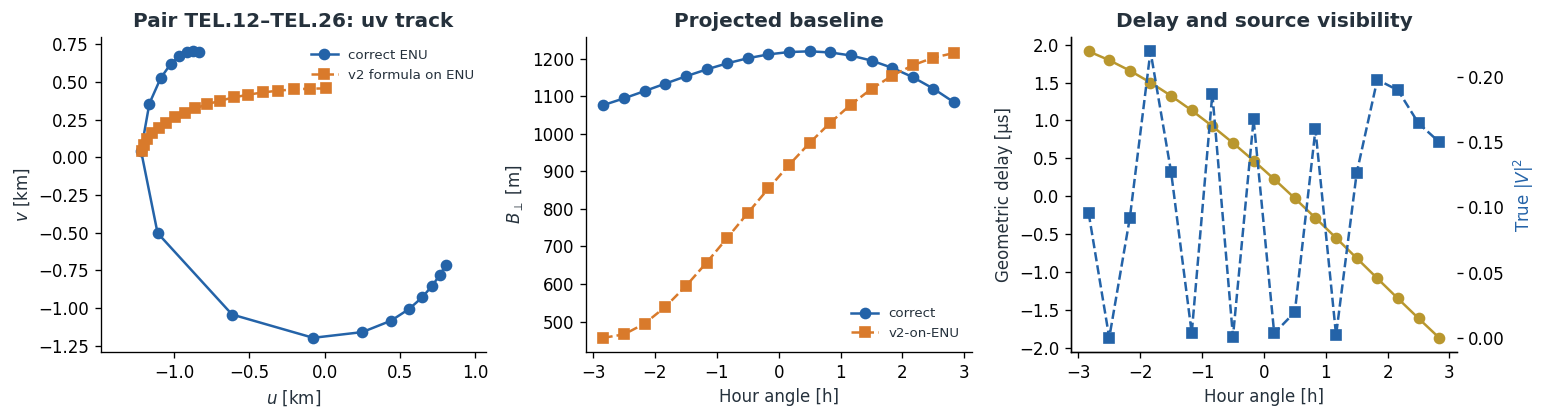

In [7]:
def source_direction_enu(hour_angle_rad, dec_rad, lat_rad):
    return np.array([
        np.cos(dec_rad) * np.sin(hour_angle_rad),
        np.sin(dec_rad) * np.cos(lat_rad) - np.cos(dec_rad) * np.cos(hour_angle_rad) * np.sin(lat_rad),
        np.sin(dec_rad) * np.sin(lat_rad) + np.cos(dec_rad) * np.cos(hour_angle_rad) * np.cos(lat_rad),
    ])

def uvw_from_enu(baseline_enu_m, hour_angle_rad, dec_rad, lat_rad):
    source = source_direction_enu(hour_angle_rad, dec_rad, lat_rad)
    source = source / np.linalg.norm(source)
    up = np.array([0.0, 0.0, 1.0])
    u_axis = np.cross(up, source)
    if np.linalg.norm(u_axis) < 1e-12:
        u_axis = np.array([1.0, 0.0, 0.0])
    else:
        u_axis /= np.linalg.norm(u_axis)
    v_axis = np.cross(source, u_axis)
    baseline = np.asarray(baseline_enu_m, float)
    return np.array([baseline @ u_axis, baseline @ v_axis, baseline @ source])

def legacy_v2_uvw_labeled_enu(baseline_enu_m, hour_angle_rad, dec_rad):
    east, north, up = baseline_enu_m
    sh, ch = np.sin(hour_angle_rad), np.cos(hour_angle_rad)
    sd, cd = np.sin(dec_rad), np.cos(dec_rad)
    return np.array([
        sh*east + ch*north,
        -sd*ch*east + sd*sh*north + cd*up,
        cd*ch*east - cd*sh*north + sd*up,
    ])

lat = np.deg2rad(INST.site_lat_deg)
dec = np.deg2rad(INST.source_dec_deg)
segment_count = int(round(INST.observing_hours*3600/INST.segment_s))
segment_hours = INST.segment_s/3600.0
hour_angles_h = np.linspace(
    -INST.observing_hours/2 + segment_hours/2,
    INST.observing_hours/2 - segment_hours/2,
    segment_count)
hour_angles_rad = hour_angles_h * np.pi / 12.0

farthest = lact_baselines.loc[lact_baselines.baseline_m.idxmax()]
baseline_vec = farthest[["east_m", "north_m", "up_m"]].to_numpy(float)
pair_track = np.array([uvw_from_enu(baseline_vec, h, dec, lat) for h in hour_angles_rad])
legacy_track = np.array([legacy_v2_uvw_labeled_enu(baseline_vec, h, dec) for h in hour_angles_rad])
projected = np.hypot(pair_track[:, 0], pair_track[:, 1])
legacy_projected = np.hypot(legacy_track[:, 0], legacy_track[:, 1])
pair_v2 = np.abs(binary_visibility(pair_track[:, 0]/INST.wavelength_m,
                                   pair_track[:, 1]/INST.wavelength_m))**2

transit = int(np.argmin(np.abs(hour_angles_h)))
pair_example = pd.DataFrame([{
    "telescope_i": farthest.name_i,
    "telescope_j": farthest.name_j,
    "B_E_m": baseline_vec[0], "B_N_m": baseline_vec[1], "B_U_m": baseline_vec[2],
    "physical_B_m": np.linalg.norm(baseline_vec),
    "transit_u_m": pair_track[transit, 0], "transit_v_m": pair_track[transit, 1],
    "transit_w_m": pair_track[transit, 2],
    "transit_projected_B_m": projected[transit],
    "transit_geometric_delay_ns": pair_track[transit, 2]/C*1e9,
    "transit_visibility2": pair_v2[transit],
}])
display(pair_example.T.rename(columns={0: "value"}).round(6))
pair_example.to_csv(OUTPUT_DIR / "farthest_pair_calculation.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.6))
axes[0].plot(pair_track[:,0]/1e3, pair_track[:,1]/1e3, "o-", color=BLUE, label="correct ENU")
axes[0].plot(legacy_track[:,0]/1e3, legacy_track[:,1]/1e3, "s--", color=ORANGE, label="v2 formula on ENU")
axes[0].set(title=f"Pair {farthest.name_i}–{farthest.name_j}: uv track", xlabel=r"$u$ [km]", ylabel=r"$v$ [km]")
axes[0].set_aspect("equal", adjustable="datalim")
axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(hour_angles_h, projected, "o-", color=BLUE, label="correct")
axes[1].plot(hour_angles_h, legacy_projected, "s--", color=ORANGE, label="v2-on-ENU")
axes[1].set(title="Projected baseline", xlabel="Hour angle [h]", ylabel=r"$B_\perp$ [m]")
axes[1].legend(frameon=False, fontsize=8)
axes[2].plot(hour_angles_h, pair_track[:,2]/C*1e6, "o-", color=GOLD, label=r"$w/c$")
ax2 = axes[2].twinx()
ax2.plot(hour_angles_h, pair_v2, "s--", color=BLUE, label=r"$|V|^2$")
axes[2].set(title="Delay and source visibility", xlabel="Hour angle [h]", ylabel="Geometric delay [µs]")
ax2.set_ylabel(r"True $|V|^2$", color=BLUE)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "two_telescope_calculation.png", bbox_inches="tight")
plt.show()

invariant_error = np.max(np.abs(np.sum(pair_track**2, axis=1) - np.dot(baseline_vec, baseline_vec)))
assert invariant_error < 1e-6

## 5. Results: 全阵列理论 (uv) 覆盖

下图把所有 (N(N-1)/2=496) 条物理基线在 6 小时内的地球自转轨迹叠加到理论功率面。图中同时画出共轭点 ((-u,-v))；这不是额外的独立测量，而是实天图傅里叶功率的厄米对称性。

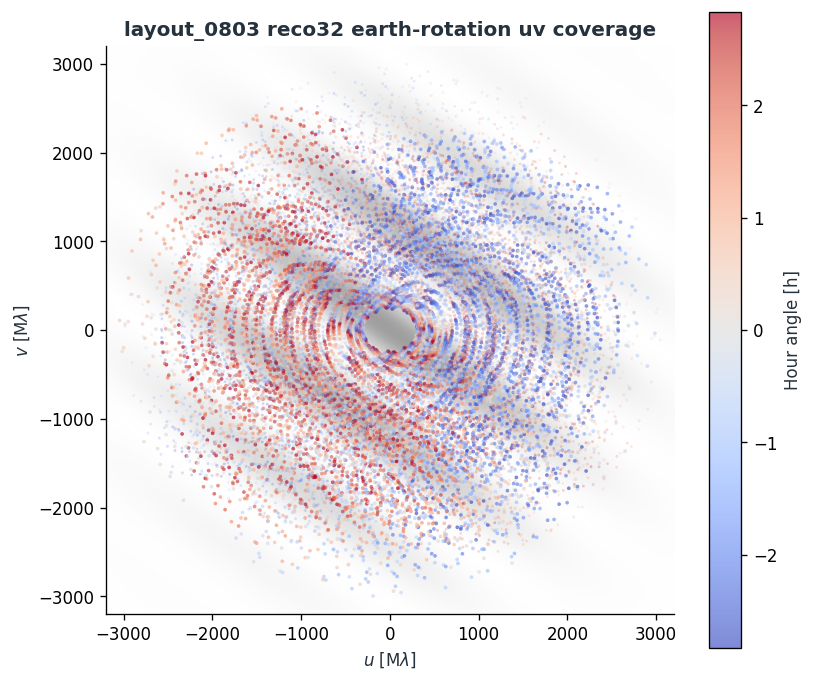

,telescope_i,telescope_j,segment,hour_angle_h,u_m,v_m,w_m,u_lambda,v_lambda,projected_baseline_m,geometric_delay_ns,visibility2_true
0,TEL.1,TEL.2,0,-2.833333,134.000230,-0.484686,0.389547,3.350006e+08,-1.211715e+06,134.001107,1.299388,0.709052
1,TEL.1,TEL.2,1,-2.500000,133.825724,-5.661789,3.881748,3.345643e+08,-1.415447e+07,133.945438,12.948116,0.735996
2,TEL.1,TEL.2,2,-2.166667,133.270083,-12.098459,7.011454,3.331752e+08,-3.024615e+07,133.818115,23.387693,0.769380
3,TEL.1,TEL.2,3,-1.833333,132.111516,-20.195015,9.754847,3.302788e+08,-5.048754e+07,133.646142,32.538667,0.810320
4,TEL.1,TEL.2,4,-1.500000,129.886956,-30.653442,12.091047,3.247174e+08,-7.663360e+07,133.455067,40.331392,0.859998


uv rows = 8,928; unique physical pairs = 496


In [8]:
def make_uv_coverage(layout, hour_angles_rad, instrument=INST):
    rows = []
    baselines = baseline_table(layout)
    for _, pair in baselines.iterrows():
        vec = pair[["east_m", "north_m", "up_m"]].to_numpy(float)
        for segment, hour_angle in enumerate(hour_angles_rad):
            u_m, v_m, w_m = uvw_from_enu(vec, hour_angle, dec, lat)
            rows.append({
                "telescope_i": pair.name_i, "telescope_j": pair.name_j,
                "segment": segment, "hour_angle_h": hour_angle*12/np.pi,
                "u_m": u_m, "v_m": v_m, "w_m": w_m,
                "u_lambda": u_m/instrument.wavelength_m,
                "v_lambda": v_m/instrument.wavelength_m,
                "projected_baseline_m": np.hypot(u_m, v_m),
                "geometric_delay_ns": w_m/C*1e9,
            })
    return pd.DataFrame(rows)

uv_coverage = make_uv_coverage(LACT32, hour_angles_rad)
uv_coverage["visibility2_true"] = np.abs(binary_visibility(
    uv_coverage.u_lambda.to_numpy(), uv_coverage.v_lambda.to_numpy()))**2

fig, axis = plt.subplots(figsize=(7.0, 6.0))
bg = axis.imshow(theory_power, origin="lower",
                 extent=np.array([-uv_limit, uv_limit, -uv_limit, uv_limit])/1e6,
                 cmap="Greys", vmin=0, vmax=1, alpha=0.38)
sc = axis.scatter(uv_coverage.u_lambda/1e6, uv_coverage.v_lambda/1e6,
                  c=uv_coverage.hour_angle_h, cmap="coolwarm", s=5, alpha=0.65, linewidth=0)
axis.scatter(-uv_coverage.u_lambda/1e6, -uv_coverage.v_lambda/1e6,
             c=uv_coverage.hour_angle_h, cmap="coolwarm", s=3, alpha=0.25, linewidth=0)
axis.set(title="layout_0803 reco32 earth-rotation uv coverage",
         xlabel=r"$u$ [M$\lambda$]", ylabel=r"$v$ [M$\lambda$]")
axis.set_aspect("equal", adjustable="box")
fig.colorbar(sc, ax=axis, label="Hour angle [h]")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "theoretical_uv_with_array_coverage.png", bbox_inches="tight")
plt.show()
display(uv_coverage.head())
print(f"uv rows = {len(uv_coverage):,}; unique physical pairs = {uv_coverage[['telescope_i','telescope_j']].drop_duplicates().shape[0]}")
pd.DataFrame([{
    "uv_rows": len(uv_coverage),
    "unique_physical_pairs": uv_coverage[["telescope_i", "telescope_j"]].drop_duplicates().shape[0],
    "maximum_projected_baseline_m": uv_coverage.projected_baseline_m.max(),
    "maximum_abs_geometric_delay_ns": uv_coverage.geometric_delay_ns.abs().max(),
}]).to_csv(OUTPUT_DIR / "uv_coverage_summary.csv", index=False)

## 6. 从光学相干到电子相关峰

对非偏振、近似带宽为 (Delta\lambda) 的通带，未分辨相关峰的面积尺度为

\[
\tau_{c,\mathrm{area}}=p\,s_{\rm band}\frac{\lambda^2}{c\,\Delta\lambda}.
\]

它是飞秒量级，远小于 625 MS/s 的 1.6 ns 采样。电子学看到的零时延峰高度因此被稀释约 (	au_c/\Delta t)，而不是把相干时间人为设成 1 ns。下图用归一化电子相关核画出这条基线在过中天时的理论峰，并展示几何时延校正前后的峰位。

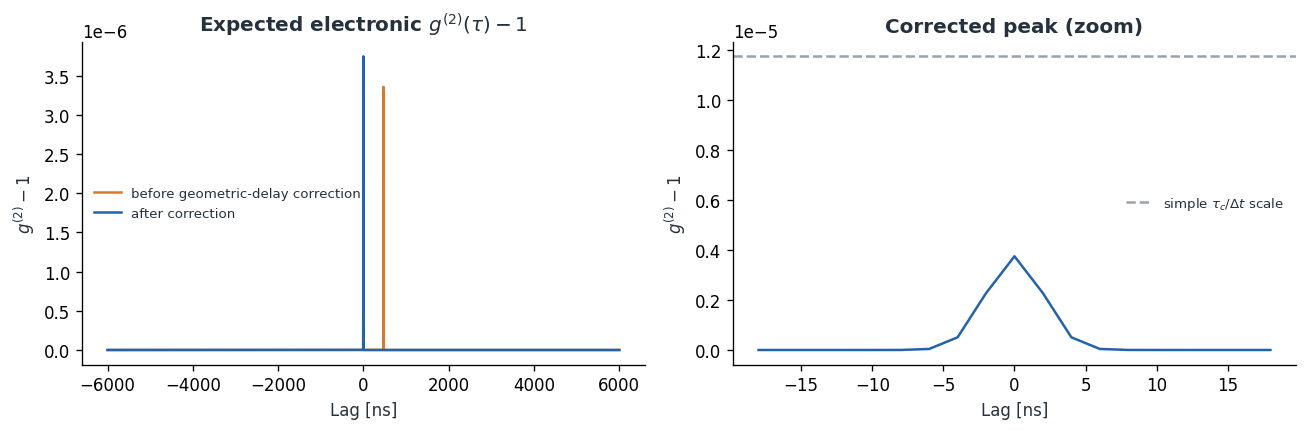

,value
coherence_area_fs,112.344387
adc_sample_width_ns,1.600000
unresolved_zero_baseline_contrast,0.000070
pair_transit_visibility2,0.167203
pair_expected_sample_contrast,0.000012


In [9]:
coherence_fs = INST.coherence_area_s * 1e15
unresolved_contrast = INST.coherence_area_s / INST.sample_width_s
star_fraction_at_m2 = None

lag_ns = np.linspace(-6000, 6000, 6001)
electronics_sigma_ns = 2.0
kernel = np.exp(-0.5*(lag_ns/electronics_sigma_ns)**2)
kernel /= np.trapezoid(kernel, lag_ns*1e-9)  # unit area in s^-1
transit_delay_ns = pair_example.loc[0, "transit_geometric_delay_ns"]
transit_visibility2 = pair_example.loc[0, "transit_visibility2"]
shifted_kernel = np.interp(lag_ns-transit_delay_ns, lag_ns, kernel, left=0, right=0)
peak_corrected = INST.coherence_area_s * transit_visibility2 * kernel
peak_uncorrected = INST.coherence_area_s * transit_visibility2 * shifted_kernel

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.7))
axes[0].plot(lag_ns, peak_uncorrected, color=ORANGE, label="before geometric-delay correction")
axes[0].plot(lag_ns, peak_corrected, color=BLUE, label="after correction")
axes[0].set(title=r"Expected electronic $g^{(2)}(\tau)-1$", xlabel="Lag [ns]", ylabel=r"$g^{(2)}-1$")
axes[0].legend(frameon=False, fontsize=8)
zoom = np.abs(lag_ns) < 20
axes[1].plot(lag_ns[zoom], peak_corrected[zoom], color=BLUE)
axes[1].axhline(unresolved_contrast*transit_visibility2, color=GREY, linestyle="--",
                label=r"simple $\tau_c/\Delta t$ scale")
axes[1].set(title="Corrected peak (zoom)", xlabel="Lag [ns]", ylabel=r"$g^{(2)}-1$")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "two_telescope_g2_peak.png", bbox_inches="tight")
plt.show()

coherence_summary = pd.DataFrame([{
    "coherence_area_fs": coherence_fs,
    "adc_sample_width_ns": INST.sample_width_s*1e9,
    "unresolved_zero_baseline_contrast": unresolved_contrast,
    "pair_transit_visibility2": transit_visibility2,
    "pair_expected_sample_contrast": unresolved_contrast*transit_visibility2,
}])
display(coherence_summary.T.rename(columns={0:"value"}))

### 6.1 2 μs 完整电子学记录与微单元恢复

这一节回答“完整波形有没有意义”：有，但用途是校准延迟、SPE 形状、ADC、基线噪声、饱和和恢复偏差；它不能单独承担小时级天文灵敏度。实测 SPE 模板支持约170–180 ns，因此有效记录扩展为2 μs（625 MS/s 下1250个采样），并在有效窗口两侧继续生成至少一个完整模板长度的光电子，避免边缘 p.e. 长尾被截断。即便如此，单采样预期 HBT 对比度仍只有约 (10^{-6})，所以单帧相关曲线必然由随机噪声主导。

输入不是人为的 1 ns 光学波形，而是每个 ADC bin 内满足正确一、二阶矩的光电子计数：两镜恒星流包含一个极小的共享 Poisson 分量，使协方差等于 (r_{\star,1}r_{\star,2}\tau_c\Delta t|V|^2)；星光余项和 NSB 独立。每个 p.e. 随机落到 270336 个微单元，电荷按

\[
q(\Delta t)=1-\exp(-\Delta t/\tau_{\rm rec})
\]

恢复，并从 537 个实测单 PE 相对电荷中逐次抽样。每个 p.e. 还从正式1229分片镜面、590239条轴上400 nm光追得到的到达时间混合分布中抽取光路延迟，然后才叠加实测 SPE 模板、0.35 mV 假设电子噪声并做 8-bit/200 mV ADC 量化。几何时延 (w/c) 先由上节计算并用数字缓冲粗校正；这里保留 0.2 ns RMS 的待标定残差。

,recovery_time_ns,analytic_mean_charge_fraction,record_mean_fraction_tel_A,record_mean_fraction_tel_B,record_pe_tel_A,record_pe_tel_B
0,1.0,0.999999,1.000000,1.0,617,689
1,10.0,0.999989,1.000000,1.0,617,689
2,30.0,0.999968,0.999908,1.0,617,689


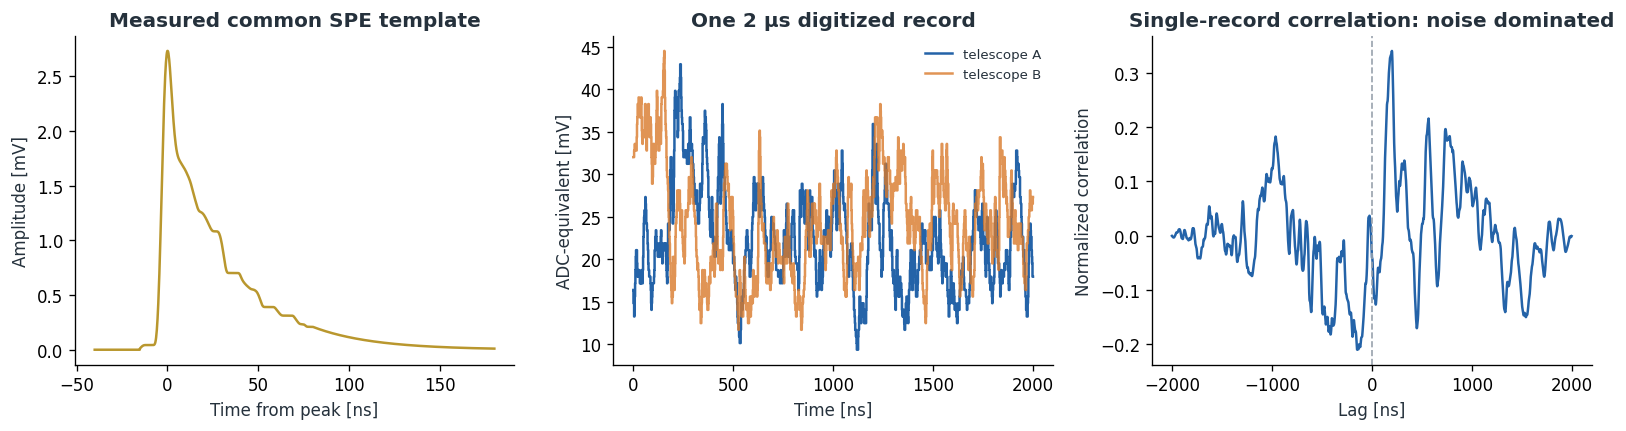

,value
duration_ns,2000.000000
simulated_padding_each_side_ns,183.209635
samples,1250.000000
star_rate_MHz,213.450224
nsb_rate_MHz,70.527000
expected_sample_contrast,0.000012
optical_arrival_rms_ns,0.601927
optical_peak_to_peak_ns,1.732313
optical_timing_efficiency_at_200MHz,0.832691
shared_correlated_counts_expected_in_record,0.001712


In [10]:
from sii_unified import (
    Instrument as ShortWaveformInstrument,
    detected_star_rate_hz as unified_detected_star_rate_hz,
    load_empirical_charge_factors,
    load_measured_spe_template,
    load_optical_timing_mixture,
    mean_recovery_fraction,
    normalized_cross_correlation,
    optical_timing_transfer_efficiency,
    residual_delay_response,
    simulate_short_pair_waveforms,
)

short_instrument = ShortWaveformInstrument(
    wavelength_nm=INST.wavelength_nm,
    optical_width_nm=INST.optical_width_nm,
    effective_area_m2=INST.effective_area_m2,
    throughput=INST.throughput,
    electronics_bandwidth_hz=INST.electronics_bandwidth_hz,
    adc_sample_rate_hz=INST.adc_sample_rate_hz,
    adc_bits=INST.adc_bits,
    adc_full_scale_mv=INST.adc_full_scale_mv,
    detected_nsb_rate_hz=INST.detected_nsb_rate_hz,
    electronic_noise_rms_mv=INST.electronic_noise_rms_mv,
    excess_noise_factor=INST.excess_noise_factor,
    polarization_factor=INST.polarization_factor,
    spectral_shape_factor=INST.spectral_shape_factor,
    microcells_per_pixel=INST.microcells_per_pixel,
    microcell_recovery_time_ns=INST.microcell_recovery_time_ns,
)
spe_t_ns, spe_mv = load_measured_spe_template(
    REPO_ROOT / "configs" / "electronics" / "parameters" / "spe_template_measured.csv"
)
empirical_charge_factors = load_empirical_charge_factors(
    REPO_ROOT / "configs" / "electronics" / "parameters" / "spe_charge_samples_measured.csv"
)
optical_timing = load_optical_timing_mixture(
    REPO_ROOT / "configs" / "optics" / "lact_1229_onaxis_timing_kernel.csv"
)
optical_timing_efficiency = optical_timing_transfer_efficiency(
    optical_timing, INST.electronics_bandwidth_hz)
reference_star_rate = unified_detected_star_rate_hz(
    INST.source_ab_magnitude, short_instrument)
short_record = simulate_short_pair_waveforms(
    duration_ns=2000.0,
    star_rate_hz=reference_star_rate,
    nsb_rate_hz=INST.detected_nsb_rate_hz,
    visibility2=float(transit_visibility2),
    instrument=short_instrument,
    template_time_ns=spe_t_ns,
    template_amplitude_mv=spe_mv,
    delay_ns=0.2,
    recovery_time_ns=10.0,
    charge_factors=empirical_charge_factors,
    optical_timing_mixture=optical_timing,
    seed=20260824,
)

recovery_rows = []
total_rate = reference_star_rate + INST.detected_nsb_rate_hz
for tau_ns in [1.0, 10.0, 30.0]:
    record = simulate_short_pair_waveforms(
        2000.0, reference_star_rate, INST.detected_nsb_rate_hz,
        float(transit_visibility2), short_instrument, spe_t_ns, spe_mv,
        delay_ns=0.2, recovery_time_ns=tau_ns,
        charge_factors=empirical_charge_factors,
        optical_timing_mixture=optical_timing, seed=20260824)
    recovery_rows.append({
        "recovery_time_ns": tau_ns,
        "analytic_mean_charge_fraction": mean_recovery_fraction(
            total_rate, INST.microcells_per_pixel, tau_ns),
        "record_mean_fraction_tel_A": np.mean(record["recovery_a"]),
        "record_mean_fraction_tel_B": np.mean(record["recovery_b"]),
        "record_pe_tel_A": len(record["pe_times_a_ns"]),
        "record_pe_tel_B": len(record["pe_times_b_ns"]),
    })
recovery_table = pd.DataFrame(recovery_rows)
display(recovery_table)
recovery_table.to_csv(OUTPUT_DIR / "microcell_recovery_sensitivity.csv", index=False)

lags, short_corr = normalized_cross_correlation(
    short_record["adc_a_mv"], short_record["adc_b_mv"])
lag_ns_short = lags * INST.sample_width_s * 1e9
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.7))
axes[0].plot(spe_t_ns, spe_mv, color=GOLD)
axes[0].set(title="Measured common SPE template", xlabel="Time from peak [ns]", ylabel="Amplitude [mV]")
axes[1].step(short_record["sample_time_ns"], short_record["adc_a_mv"], where="mid", color=BLUE, label="telescope A")
axes[1].step(short_record["sample_time_ns"], short_record["adc_b_mv"], where="mid", color=ORANGE, alpha=.8, label="telescope B")
axes[1].set(title="One 2 μs digitized record", xlabel="Time [ns]", ylabel="ADC-equivalent [mV]")
axes[1].legend(frameon=False, fontsize=8)
axes[2].plot(lag_ns_short, short_corr, color=BLUE)
axes[2].axvline(0, color=GREY, linestyle="--", linewidth=1)
axes[2].set(title="Single-record correlation: noise dominated", xlabel="Lag [ns]", ylabel="Normalized correlation")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "short_waveform_and_recovery.png", bbox_inches="tight")
plt.show()

short_waveform_summary = pd.DataFrame([{
    "duration_ns": 2000.0,
    "simulated_padding_each_side_ns": short_record["simulated_padding_each_side_ns"],
    "samples": len(short_record["sample_time_ns"]),
    "star_rate_MHz": reference_star_rate / 1e6,
    "nsb_rate_MHz": INST.detected_nsb_rate_hz / 1e6,
    "expected_sample_contrast": short_record["expected_sample_contrast"],
    "optical_arrival_rms_ns": optical_timing["rms_spread_ns"],
    "optical_peak_to_peak_ns": 1.7323132,
    "optical_timing_efficiency_at_200MHz": optical_timing_efficiency,
    "shared_correlated_counts_expected_in_record": (
        short_record["shared_count_mean_per_bin"] * len(short_record["sample_time_ns"])),
    "empirical_charge_samples": len(empirical_charge_factors),
    "sampled_charge_mean_A": np.mean(short_record["charge_a"]),
    "sampled_charge_rms_A": np.sqrt(np.mean(short_record["charge_a"]**2)),
    "adc_clipped_fraction_A": np.mean(np.abs(short_record["adc_a_mv"]) >= INST.adc_full_scale_mv/2 - INST.adc_full_scale_mv/2**INST.adc_bits),
}])
display(short_waveform_summary.T.rename(columns={0:"value"}))
short_waveform_summary.to_csv(OUTPUT_DIR / "short_waveform_summary.csv", index=False)

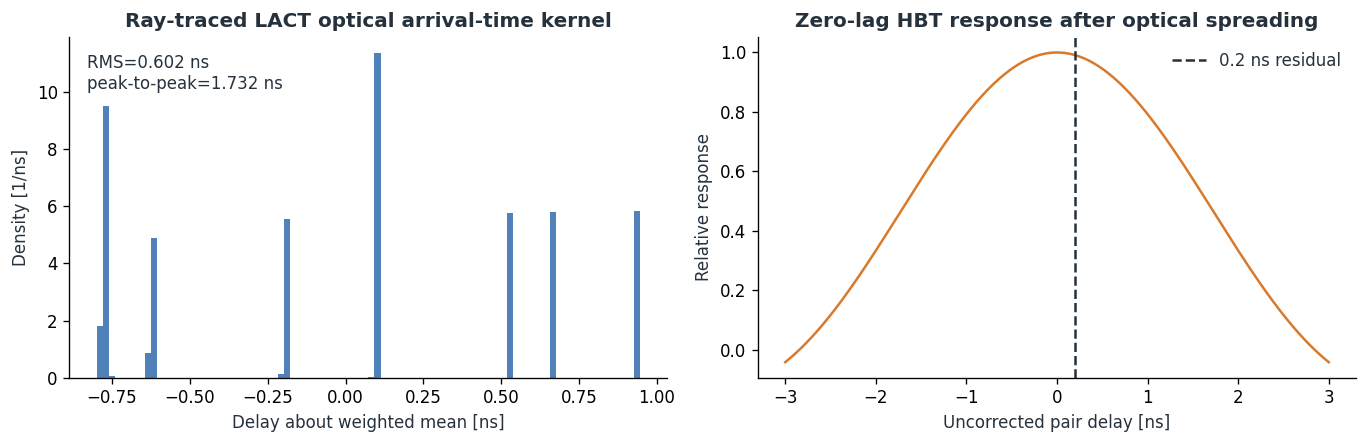

,value
ray_count,590239.000000
facet_components,54.000000
arrival_rms_ns,0.601927
arrival_peak_to_peak_ns,1.732313
band_averaged_contrast_retained,0.832691
visibility2_sigma_inflation_after_calibration,1.200925
response_at_0p2ns_residual,0.991094


In [11]:
timing_kernel_frame = pd.read_csv(
    REPO_ROOT / "configs" / "optics" / "lact_1229_onaxis_timing_kernel.csv")
timing_rng = np.random.default_rng(20260824)
timing_component = timing_rng.choice(
    len(timing_kernel_frame), size=200000,
    p=timing_kernel_frame.weight/timing_kernel_frame.weight.sum())
timing_draws = timing_rng.normal(
    timing_kernel_frame.mean_time_ns.to_numpy()[timing_component],
    timing_kernel_frame.std_time_ns.to_numpy()[timing_component])
timing_draws -= np.average(timing_kernel_frame.mean_time_ns,
                           weights=timing_kernel_frame.weight)
delay_scan_ns = np.linspace(-3.0, 3.0, 301)
delay_response = residual_delay_response(
    optical_timing, delay_scan_ns, INST.electronics_bandwidth_hz)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
axes[0].hist(timing_draws, bins=90, density=True, color=BLUE, alpha=.8)
axes[0].set(title="Ray-traced LACT optical arrival-time kernel",
            xlabel="Delay about weighted mean [ns]", ylabel="Density [1/ns]")
axes[0].text(.03, .95,
             f"RMS={optical_timing['rms_spread_ns']:.3f} ns\n"
             f"peak-to-peak=1.732 ns",
             transform=axes[0].transAxes, va="top")
axes[1].plot(delay_scan_ns, delay_response, color=ORANGE)
axes[1].axvline(0.2, color=INK, linestyle="--", label="0.2 ns residual")
axes[1].set(title="Zero-lag HBT response after optical spreading",
            xlabel="Uncorrected pair delay [ns]", ylabel="Relative response")
axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR/"optical_arrival_time_response.png", bbox_inches="tight")
plt.show()
display(pd.DataFrame([{
    "ray_count": int(timing_kernel_frame["count"].sum()),
    "facet_components": len(timing_kernel_frame),
    "arrival_rms_ns": optical_timing["rms_spread_ns"],
    "arrival_peak_to_peak_ns": (
        timing_kernel_frame.max_time_ns.max()-timing_kernel_frame.min_time_ns.min()),
    "band_averaged_contrast_retained": optical_timing_efficiency,
    "visibility2_sigma_inflation_after_calibration": 1/optical_timing_efficiency,
    "response_at_0p2ns_residual": float(residual_delay_response(
        optical_timing, np.array([0.2]), INST.electronics_bandwidth_hz)[0]),
}]).T.rename(columns={0:"value"}))

## 7. 模拟的 (uv) 测量：星等、NSB、电子带宽与误差

AB 星等先转成每单位频率光子谱密度 (n_\nu=F_\nu/(h\nu))，再得到已探测星光率 (r_\star=A\eta n_\nu\Delta\nu)。每个 20 min 段生成一个不裁剪的高斯近似 (|V|^2) 估计和显式 `sigma_visibility2`。这是长曝光相关器的充分统计量，不生成一整夜的 625 MS/s 原始波形。

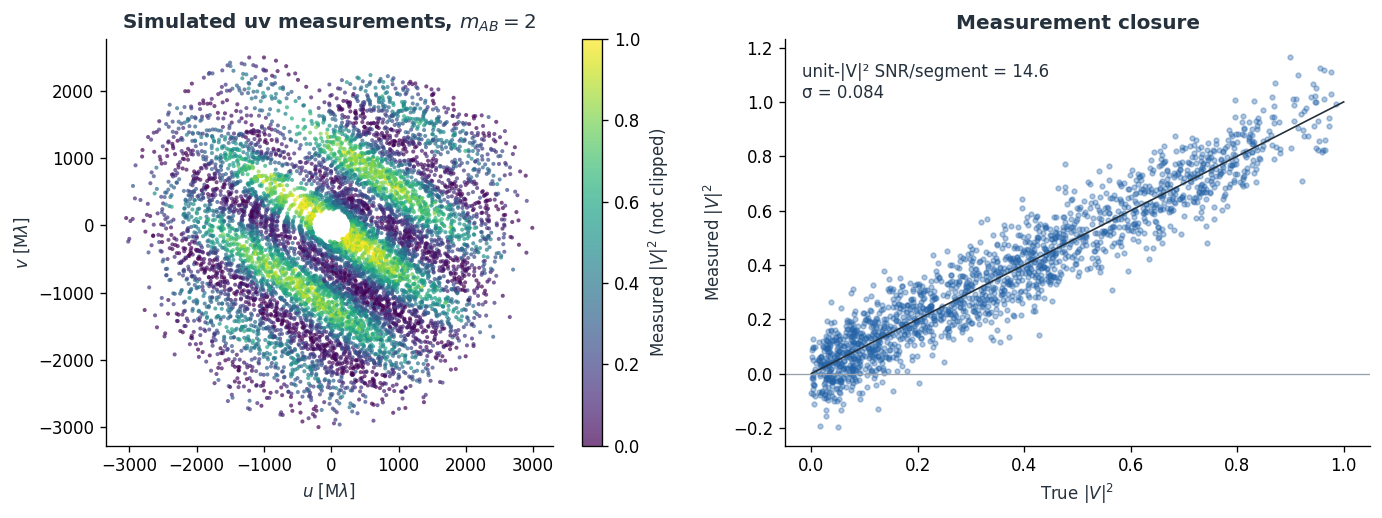

,value
source_ab_magnitude,2.000000
detected_star_rate_MHz,213.450224
detected_nsb_rate_MHz,70.527000
unit_visibility_snr_per_segment,14.595374
optical_timing_efficiency,0.832691
sigma_visibility2_total,0.083637
negative_measurement_fraction,0.059140


In [12]:
def ab_photon_spectral_density(magnitude, wavelength_m=INST.wavelength_m):
    f_nu = 3631.0 * JY * 10**(-0.4*magnitude)
    return f_nu / (H_PLANCK * C / wavelength_m)

def detected_star_rate_hz(magnitude, instrument=INST):
    return (instrument.collecting_area_m2 * instrument.throughput
            * ab_photon_spectral_density(magnitude, instrument.wavelength_m)
            * instrument.optical_bandwidth_hz)

def unit_visibility_snr(magnitude, integration_s, instrument=INST,
                        spectral_channels=1, nsb_rate_hz=None):
    nsb = instrument.detected_nsb_rate_hz if nsb_rate_hz is None else nsb_rate_hz
    star = detected_star_rate_hz(magnitude, instrument)
    total = star + nsb
    one_channel = (star**2 / (total * instrument.optical_bandwidth_hz)
                   * np.sqrt(instrument.electronics_bandwidth_hz * integration_s / 2)
                   / instrument.excess_noise_factor)
    return one_channel * np.sqrt(spectral_channels)

unit_snr = unit_visibility_snr(INST.source_ab_magnitude, INST.segment_s)
# The ray-traced optical kernel retains only this fraction of the
# zero-lag HBT contrast. Correcting it back to |V|^2 inflates sigma.
sigma_stat = 1.0 / (unit_snr * optical_timing_efficiency)
sigma_total = np.sqrt(sigma_stat**2 + INST.calibration_floor_visibility2**2)
simulated_uv = uv_coverage.copy()
simulated_uv["sigma_visibility2_stat"] = sigma_stat
simulated_uv["sigma_visibility2"] = sigma_total
simulated_uv["visibility2_measured"] = (
    simulated_uv.visibility2_true + RNG.normal(0, sigma_total, len(simulated_uv))
)
simulated_uv["expected_snr"] = simulated_uv.visibility2_true / sigma_total
simulated_uv.to_csv(OUTPUT_DIR / "simulated_uv_measurements.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))
sc = axes[0].scatter(simulated_uv.u_lambda/1e6, simulated_uv.v_lambda/1e6,
                     c=simulated_uv.visibility2_measured, cmap="viridis",
                     vmin=0, vmax=1, s=6, alpha=0.70, linewidth=0)
axes[0].set(title=rf"Simulated uv measurements, $m_{{AB}}={INST.source_ab_magnitude:g}$",
            xlabel=r"$u$ [M$\lambda$]", ylabel=r"$v$ [M$\lambda$]")
axes[0].set_aspect("equal", adjustable="box")
fig.colorbar(sc, ax=axes[0], label=r"Measured $|V|^2$ (not clipped)")
sample = simulated_uv.sample(min(1800, len(simulated_uv)), random_state=20260823)
axes[1].scatter(sample.visibility2_true, sample.visibility2_measured,
                s=8, alpha=0.35, color=BLUE)
axes[1].plot([0,1], [0,1], color=INK, linewidth=1)
axes[1].axhline(0, color=GREY, linewidth=0.8)
axes[1].set(title="Measurement closure", xlabel=r"True $|V|^2$", ylabel=r"Measured $|V|^2$")
axes[1].text(0.03, 0.94, f"unit-|V|² SNR/segment = {unit_snr:.1f}\nσ = {sigma_total:.3f}",
             transform=axes[1].transAxes, va="top")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "simulated_uv_measurements.png", bbox_inches="tight")
plt.show()

measurement_summary = pd.DataFrame([{
    "source_ab_magnitude": INST.source_ab_magnitude,
    "detected_star_rate_MHz": detected_star_rate_hz(INST.source_ab_magnitude)/1e6,
    "detected_nsb_rate_MHz": INST.detected_nsb_rate_hz/1e6,
    "unit_visibility_snr_per_segment": unit_snr,
    "optical_timing_efficiency": optical_timing_efficiency,
    "sigma_visibility2_total": sigma_total,
    "negative_measurement_fraction": np.mean(simulated_uv.visibility2_measured < 0),
}])
display(measurement_summary.T.rename(columns={0:"value"}))

## 8. 无相位、非参数重建

使用本分支 `python/sii_reconstruction.py` 的 `positive_softmax_multistart_lbfgsb`：

- 像素强度由 softmax 参数化，严格非负且总流量为 1；
- 只在有限圆形支撑域内优化；
- 损失是带每点误差权重的 Huber (|V|^2) 残差，加二次平滑正则；
- 多起点 L-BFGS-B 缓解非凸局部极值；
- 真值绝不进入优化，仅在完成后对允许的平移和 180°镜像进行验证。

为控制矩阵规模，先在 (uv) 平面作逆方差加权分箱；分箱是数据压缩，不插值、不制造未观测 (uv) 点。零基线点作为独立的总流量标定加入。

In [13]:
from sii_reconstruction import UvData, reconstruct_uv_data

def bin_uv_measurements(frame, cell_mlambda=120.0):
    data = frame.copy()
    data["ku"] = np.round(data.u_lambda/1e6/cell_mlambda).astype(int)
    data["kv"] = np.round(data.v_lambda/1e6/cell_mlambda).astype(int)
    data["inverse_variance"] = 1.0 / data.sigma_visibility2**2
    data["weighted_value"] = data.visibility2_measured * data.inverse_variance
    grouped = data.groupby(["ku","kv"], as_index=False).agg(
        u_lambda=("u_lambda", "mean"),
        v_lambda=("v_lambda", "mean"),
        weighted_value=("weighted_value", "sum"),
        inverse_variance=("inverse_variance", "sum"),
        multiplicity=("visibility2_measured", "size"),
    )
    grouped["visibility2"] = grouped.weighted_value / grouped.inverse_variance
    grouped["sigma"] = np.sqrt(1.0/grouped.inverse_variance)
    return grouped

binned = bin_uv_measurements(simulated_uv)
binned = pd.concat([binned, pd.DataFrame([{
    "ku":0, "kv":0, "u_lambda":0.0, "v_lambda":0.0,
    "weighted_value":10_000.0, "inverse_variance":10_000.0,
    "multiplicity":1, "visibility2":1.0, "sigma":0.01,
}])], ignore_index=True)
weights = 1.0 / binned.sigma.to_numpy()**2
weights = np.clip(weights/np.mean(weights), 0.1, 10.0)
weights /= weights.mean()
uv_data = UvData(
    u_lambda=binned.u_lambda.to_numpy(float),
    v_lambda=binned.v_lambda.to_numpy(float),
    visibility_abs2=binned.visibility2.to_numpy(float),
    sigma=binned.sigma.to_numpy(float),
    weight=weights,
    multiplicity=binned.multiplicity.to_numpy(int),
    input_rows=len(simulated_uv),
    finite_rows=len(simulated_uv),
    physical_violations=int(((binned.visibility2<0)|(binned.visibility2>1)).sum()),
)

result = reconstruct_uv_data(
    uv_data,
    grid_size=28,
    fov_mas=0.70,
    support_radius_mas=0.32,
    starts=4,
    max_iter=900,
    smoothness=0.020,
    huber_delta=0.15,
    seed=20260823,
    peak_minimum_separation_mas=0.10,
)
print({k:v for k,v in result.metrics.items() if not isinstance(v, np.ndarray)})
print(f"binned uv points: {len(binned):,} from {len(simulated_uv):,} measurements")

{'algorithm': 'positive_softmax_multistart_lbfgsb', 'objective': 0.00316657591852777, 'fit_rmse': 0.06160077993020822, 'weighted_fit_rmse': 0.043507041965953154, 'fit_mae': 0.04522371011991178, 'selected_start': 2, 'starts': 4, 'optimizer_success': True, 'optimizer_status': 0, 'optimizer_message': 'CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL', 'optimizer_iterations': 256, 'grid_size': 28, 'fov_mas': 0.7, 'pixel_scale_mas': 0.025925925925925908, 'support_radius_mas': 0.32, 'smoothness': 0.02, 'huber_delta': 0.15, 'seed': 20260823, 'input_rows': 8928, 'finite_rows': 8928, 'unique_uv_samples': 1562, 'physical_visibility_violations': 100, 'uses_uncertainty_weights': True, 'centroid_before_gauge_fix_pixels': [16.503566268122693, 11.718952352437174], 'centering_shift_pixels': [-3, 2], 'ambiguities': ['absolute image translation is not observable from visibility magnitude', 'a 180-degree image mirror has the same visibility magnitude'], 'peaks': [{'theta_x_mas': -0.03888888888888886, 'th

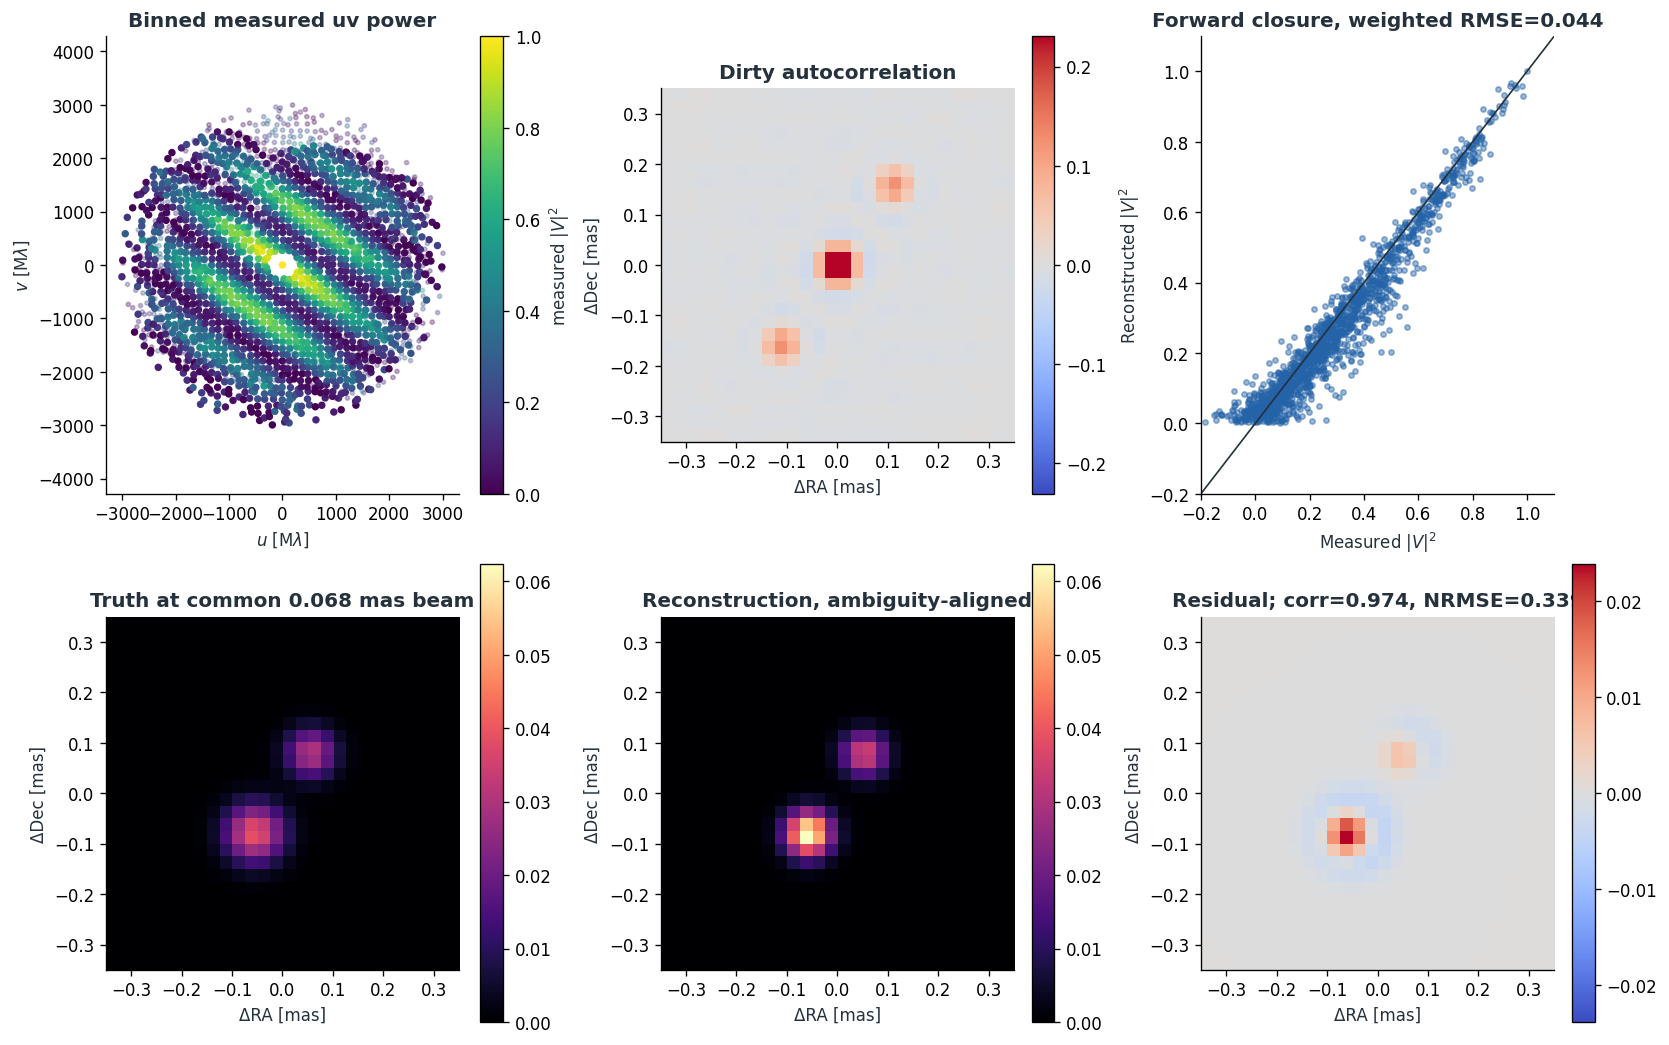

,value
true_separation_mas,0.2
recovered_separation_mas,0.223023
true_position_angle_deg,35.0
recovered_position_angle_deg,35.537678
true_flux_ratio,0.55
recovered_peak_ratio,0.551112
weighted_forward_rmse,0.043507
raw_truth_correlation,0.869926
common_beam_truth_correlation,0.973607
common_beam_truth_nrmse,0.339247


In [14]:
def grid_truth_on_reconstruction(theta, source=SOURCE):
    xx, yy = np.meshgrid(theta, theta)
    (x1,y1),(x2,y2) = binary_offsets_rad(source)
    x1,y1,x2,y2 = np.array([x1,y1,x2,y2])*RAD_TO_MAS
    pixel = abs(theta[1]-theta[0])
    s1 = max(source.primary_diameter_mas/2, 0.65*pixel)
    s2 = max(source.secondary_diameter_mas/2, 0.65*pixel)
    truth = np.exp(-((xx-x1)**2+(yy-y1)**2)/(2*s1**2))
    comp2 = np.exp(-((xx-x2)**2+(yy-y2)**2)/(2*s2**2))
    comp2 *= source.flux_ratio_secondary_to_primary * truth.sum()/comp2.sum()
    truth += comp2
    return truth/truth.sum()

def ambiguity_align(candidate, truth):
    best = None
    for mirrored, image in [(False,candidate), (True,candidate[::-1,::-1])]:
        corr = np.fft.ifft2(np.fft.fft2(truth)*np.conj(np.fft.fft2(image))).real
        iy, ix = np.unravel_index(np.argmax(corr), corr.shape)
        sy = iy if iy <= image.shape[0]//2 else iy-image.shape[0]
        sx = ix if ix <= image.shape[1]//2 else ix-image.shape[1]
        aligned = np.roll(image, (sy,sx), axis=(0,1))
        coefficient = np.corrcoef(aligned.ravel(), truth.ravel())[0,1]
        if best is None or coefficient > best[0]:
            best = coefficient, aligned, mirrored, (sy,sx)
    return best

truth_reco = grid_truth_on_reconstruction(result.theta_mas)
truth_corr_raw, aligned_reco_raw, used_mirror, shift = ambiguity_align(result.image, truth_reco)
# Compare at the actual nominal fringe scale of this array, lambda/Bmax.
reconstruction_pixel_mas = abs(result.theta_mas[1] - result.theta_mas[0])
comparison_beam_fwhm_mas = INST.wavelength_m / lact_baselines.baseline_m.max() * RAD_TO_MAS
comparison_beam_sigma_pixels = comparison_beam_fwhm_mas / (2.355 * reconstruction_pixel_mas)
aligned_reco = gaussian_filter(aligned_reco_raw, comparison_beam_sigma_pixels)
truth_reco = gaussian_filter(truth_reco, comparison_beam_sigma_pixels)
aligned_reco /= aligned_reco.sum()
truth_reco /= truth_reco.sum()
truth_corr = np.corrcoef(aligned_reco.ravel(), truth_reco.ravel())[0,1]
truth_nrmse = np.sqrt(np.mean((aligned_reco-truth_reco)**2))/(np.sqrt(np.mean(truth_reco**2))+1e-15)
extent_reco = [result.theta_mas[0], result.theta_mas[-1], result.theta_mas[0], result.theta_mas[-1]]

fig, axes = plt.subplots(2, 3, figsize=(13.8, 8.6), constrained_layout=True)
sc = axes[0,0].scatter(uv_data.u_lambda/1e6, uv_data.v_lambda/1e6,
                       c=uv_data.visibility_abs2, cmap="viridis", vmin=0, vmax=1, s=12)
axes[0,0].scatter(-uv_data.u_lambda/1e6, -uv_data.v_lambda/1e6,
                  c=uv_data.visibility_abs2, cmap="viridis", vmin=0, vmax=1, s=6, alpha=.3)
axes[0,0].set(title="Binned measured uv power", xlabel=r"$u$ [M$\lambda$]", ylabel=r"$v$ [M$\lambda$]")
axes[0,0].set_aspect("equal", adjustable="datalim")
fig.colorbar(sc, ax=axes[0,0], label=r"measured $|V|^2$")
lim = max(abs(result.dirty_autocorrelation.min()), abs(result.dirty_autocorrelation.max()))
im = axes[0,1].imshow(result.dirty_autocorrelation, origin="lower", extent=extent_reco,
                      cmap="coolwarm", vmin=-lim, vmax=lim)
axes[0,1].set(title="Dirty autocorrelation", xlabel="ΔRA [mas]", ylabel="ΔDec [mas]")
fig.colorbar(im, ax=axes[0,1])
axes[0,2].scatter(uv_data.visibility_abs2, result.predicted_visibility_abs2,
                  s=10, alpha=.45, color=BLUE)
axes[0,2].plot([-0.2,1.1],[-0.2,1.1], color=INK, linewidth=1)
axes[0,2].set(title=f"Forward closure, weighted RMSE={result.metrics['weighted_fit_rmse']:.3f}",
              xlabel=r"Measured $|V|^2$", ylabel=r"Reconstructed $|V|^2$", xlim=(-.2,1.1), ylim=(-.2,1.1))
vmax = max(truth_reco.max(), aligned_reco.max())
for axis, image, title in [
    (axes[1,0], truth_reco, f"Truth at common {comparison_beam_fwhm_mas:.3f} mas beam"),
    (axes[1,1], aligned_reco, "Reconstruction, ambiguity-aligned"),
]:
    art = axis.imshow(image, origin="lower", extent=extent_reco, cmap="magma", vmin=0, vmax=vmax)
    axis.set(title=title, xlabel="ΔRA [mas]", ylabel="ΔDec [mas]")
    fig.colorbar(art, ax=axis)
diff = aligned_reco-truth_reco
dl = max(abs(diff.min()),abs(diff.max()))
art = axes[1,2].imshow(diff, origin="lower", extent=extent_reco, cmap="coolwarm", vmin=-dl, vmax=dl)
axes[1,2].set(title=f"Residual; corr={truth_corr:.3f}, NRMSE={truth_nrmse:.3f}", xlabel="ΔRA [mas]", ylabel="ΔDec [mas]")
fig.colorbar(art, ax=axes[1,2])
fig.savefig(OUTPUT_DIR / "phaseless_reconstruction.png", bbox_inches="tight")
plt.show()

reconstruction_summary = pd.DataFrame([{
    "true_separation_mas": SOURCE.separation_mas,
    "recovered_separation_mas": result.metrics.get("two_peak_separation_mas"),
    "true_position_angle_deg": SOURCE.position_angle_deg,
    "recovered_position_angle_deg": result.metrics.get("two_peak_position_angle_deg"),
    "true_flux_ratio": SOURCE.flux_ratio_secondary_to_primary,
    "recovered_peak_ratio": result.metrics.get("two_peak_brightness_ratio"),
    "weighted_forward_rmse": result.metrics["weighted_fit_rmse"],
    "raw_truth_correlation": truth_corr_raw,
    "common_beam_truth_correlation": truth_corr,
    "common_beam_truth_nrmse": truth_nrmse,
    "used_180_degree_mirror_for_validation": used_mirror,
}])
display(reconstruction_summary.T.rename(columns={0:"value"}))
reconstruction_summary.to_csv(OUTPUT_DIR / "reconstruction_summary.csv", index=False)

np.save(OUTPUT_DIR / "reconstruction_image.npy", result.image)
pd.DataFrame({
    "theta_x_mas": np.tile(result.theta_mas, len(result.theta_mas)),
    "theta_y_mas": np.repeat(result.theta_mas, len(result.theta_mas)),
    "brightness": result.image.ravel(),
}).to_csv(OUTPUT_DIR / "reconstruction_image.csv", index=False)

## 9. 几种情况：能看到多少星等，角分辨率是多少

这里区分三个概念：

1. `fringe_scale = λ/Bmax`：最长投影基线对应的名义角尺度；
2. `uniform_disk_first_null = 1.22 λ/Bmax`：均匀圆盘第一零点可被最长基线采到时的直径尺度；
3. 星等极限：在未解析源 (|V|^2=1) 上达到指定 SNR 的 AB 星等。它随源被分辨后的 (|V|^2)、NSB、系统效率和系统误差恶化。

光谱复用假设各通道具有相同电子带宽且统计独立，因此总 SNR 按 (sqrt{N_{ch}}) 提升。这是硬件情景，不是免费增益。

### 星等极限（单条未解析基线）

,NSB_case,hours,spectral_channels,m_AB_at_SNR5,m_AB_at_SNR10
0,ideal dark (0 MHz),1,1,4.069,3.317
1,ideal dark (0 MHz),1,16,5.575,4.822
2,ideal dark (0 MHz),10,1,5.319,4.567
3,ideal dark (0 MHz),10,16,6.825,6.072
4,ideal dark (0 MHz),50,1,6.193,5.441
5,ideal dark (0 MHz),50,16,7.698,6.946
6,reference NSB (70.527 MHz),1,1,3.278,2.762
7,reference NSB (70.527 MHz),1,16,4.207,3.757
8,reference NSB (70.527 MHz),10,1,4.057,3.598
9,reference NSB (70.527 MHz),10,16,4.911,4.493


### 角尺度

,layout,Bmin_m,Bmax_m,fringe_scale_mas,uniform_disk_first_null_mas,largest_scale_lambda_over_Bmin_mas
0,branch_7,40.0000,224.7221,0.3671,0.4479,2.0626
1,layout_0803_reco32,121.0055,1219.2096,0.0677,0.0826,0.6818


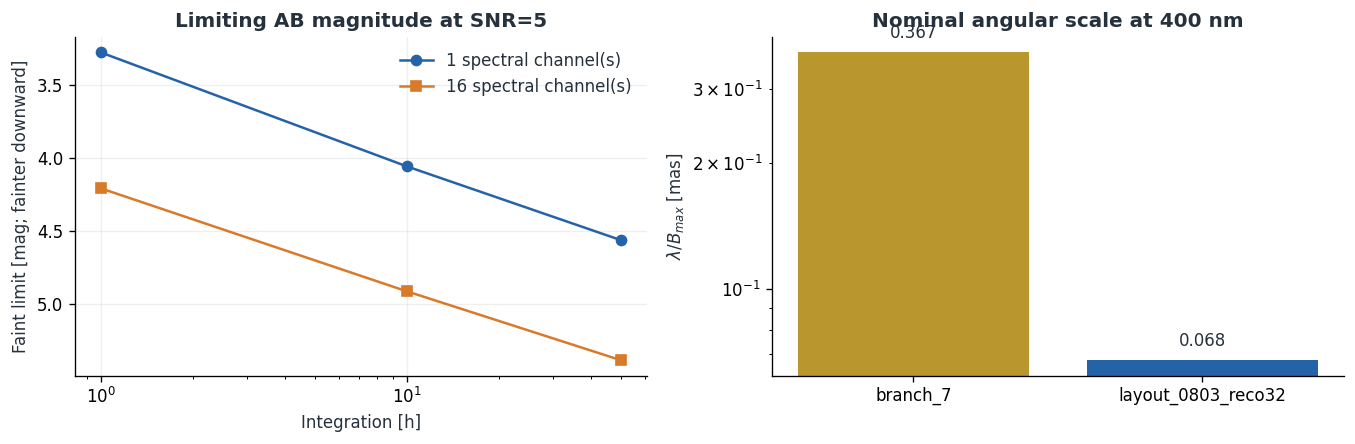

In [15]:
def limiting_magnitude(target_snr, hours, spectral_channels=1, nsb_rate_hz=None):
    return brentq(
        lambda mag: unit_visibility_snr(mag, hours*3600, INST,
                                        spectral_channels, nsb_rate_hz)-target_snr,
        -8.0, 18.0,
    )

sensitivity_rows = []
for nsb_label, nsb_rate in [("ideal dark (0 MHz)",0.0), ("reference NSB (70.527 MHz)",70.527e6)]:
    for hours in [1,10,50]:
        for channels in [1,16]:
            sensitivity_rows.append({
                "NSB_case": nsb_label, "hours":hours, "spectral_channels":channels,
                "m_AB_at_SNR5":limiting_magnitude(5,hours,channels,nsb_rate),
                "m_AB_at_SNR10":limiting_magnitude(10,hours,channels,nsb_rate),
            })
sensitivity_table = pd.DataFrame(sensitivity_rows)

resolution_rows = []
for name, baselines in [("branch_7",branch_baselines),("layout_0803_reco32",lact_baselines)]:
    bmax = baselines.baseline_m.max()
    positive = baselines.loc[baselines.baseline_m>0,"baseline_m"]
    bmin = positive.min()
    resolution_rows.append({
        "layout":name, "Bmin_m":bmin, "Bmax_m":bmax,
        "fringe_scale_mas":INST.wavelength_m/bmax*RAD_TO_MAS,
        "uniform_disk_first_null_mas":1.22*INST.wavelength_m/bmax*RAD_TO_MAS,
        "largest_scale_lambda_over_Bmin_mas":INST.wavelength_m/bmin*RAD_TO_MAS,
    })
resolution_table = pd.DataFrame(resolution_rows)
display(Markdown("### 星等极限（单条未解析基线）"))
display(sensitivity_table.round(3))
display(Markdown("### 角尺度"))
display(resolution_table.round(4))

fig, axes = plt.subplots(1,2,figsize=(11.4,3.8))
reference = sensitivity_table[sensitivity_table.NSB_case.str.startswith("reference")]
for channels,color,marker in [(1,BLUE,"o"),(16,ORANGE,"s")]:
    subset=reference[reference.spectral_channels==channels]
    axes[0].plot(subset.hours,subset.m_AB_at_SNR5,marker=marker,color=color,label=f"{channels} spectral channel(s)")
axes[0].set_xscale("log")
axes[0].invert_yaxis()
axes[0].set(title="Limiting AB magnitude at SNR=5",xlabel="Integration [h]",ylabel="Faint limit [mag; fainter downward]")
axes[0].legend(frameon=False)
axes[0].grid(alpha=.2)
axes[1].bar(resolution_table.layout,resolution_table.fringe_scale_mas,color=[GOLD,BLUE])
axes[1].set_yscale("log")
axes[1].set(title="Nominal angular scale at 400 nm",ylabel=r"$\lambda/B_{max}$ [mas]")
for i,val in enumerate(resolution_table.fringe_scale_mas): axes[1].text(i,val*1.08,f"{val:.3f}",ha="center")
fig.tight_layout()
fig.savefig(OUTPUT_DIR/"sensitivity_and_resolution.png",bbox_inches="tight")
plt.show()

sensitivity_table.to_csv(OUTPUT_DIR/"limiting_magnitude_cases.csv",index=False)
resolution_table.to_csv(OUTPUT_DIR/"angular_resolution_cases.csv",index=False)

## 10. 观测时长、NSB 和电子学：逐情景重新模拟与重建

这里采用**单变量受控比较**，不是把参数任意混成一个难以解释的全因子网格。基准为单夜 6 h、参考 NSB、现实电子学；然后分别改变：

- 单夜窗口：2、6、10 h。每个 20 min 段仍是一个独立 UV 测量，所以扩大单夜窗口主要增加不同 UV 点；
- 多夜累计：同一 ±3 h 窗口重复 5 或 10 夜，总计 30/60 h。UV 位置不变，统计误差按 (1/\sqrt{N_{night}}) 降低；
- NSB：0、1、2 倍参考暗夜背景；
- 电子学：理想计数器，或实测电荷涨落加 0.35 mV 噪声和 8-bit ADC 的参考链路。

现实电子学的附加相关效率由实测 SPE 脉冲的 Poisson shot-noise 方差

\[
\sigma_{\rm shot}^2=r_{\rm total}E[q^2]\int h^2(t)dt
\]

与电子噪声、ADC 量化噪声比较得到。它是明确的近似传播，不代替实际跨镜相关器标定。10 h 单夜延伸到 ±5 h；当前源在窗口端高度约 23°，因为尚未加入随高度变化的大气消光和 NSB，该情景特意标为乐观。

In [16]:
charge_second_moment = float(np.mean(empirical_charge_factors**2))
total_reference_rate_per_ns = (
    detected_star_rate_hz(INST.source_ab_magnitude) + INST.detected_nsb_rate_hz
) / 1e9
spe_energy_mv2_ns = float(np.trapezoid(spe_mv**2, spe_t_ns))
shot_variance_mv2 = (
    total_reference_rate_per_ns * charge_second_moment * spe_energy_mv2_ns
)
adc_step_mv = INST.adc_full_scale_mv / 2**INST.adc_bits
adc_quantization_variance_mv2 = adc_step_mv**2 / 12.0
additive_variance_mv2 = (
    INST.electronic_noise_rms_mv**2 + adc_quantization_variance_mv2
)
electronics_correlation_efficiency = (
    shot_variance_mv2 / (shot_variance_mv2 + additive_variance_mv2)
)
electronics_budget = pd.DataFrame([{
    "empirical_charge_second_moment": charge_second_moment,
    "spe_energy_mv2_ns": spe_energy_mv2_ns,
    "reference_shot_variance_mv2": shot_variance_mv2,
    "electronic_noise_variance_mv2": INST.electronic_noise_rms_mv**2,
    "adc_step_mv": adc_step_mv,
    "adc_quantization_variance_mv2": adc_quantization_variance_mv2,
    "reference_correlation_efficiency": electronics_correlation_efficiency,
}])
display(electronics_budget.T.rename(columns={0:"value"}))
electronics_budget.to_csv(OUTPUT_DIR/"electronics_noise_budget.csv", index=False)

,value
empirical_charge_second_moment,1.032545
spe_energy_mv2_ns,105.282636
reference_shot_variance_mv2,30.870905
electronic_noise_variance_mv2,0.122500
adc_step_mv,0.781250
adc_quantization_variance_mv2,0.050863
reference_correlation_efficiency,0.994416


In [17]:
def minimum_altitude_deg(hours):
    endpoints = np.array([-hours/2, hours/2]) * np.pi/12
    return float(np.min([
        np.rad2deg(np.arcsin(source_direction_enu(h, dec, lat)[2]))
        for h in endpoints
    ]))

timing_grid_ns = np.linspace(-3.0, 3.0, 2401)
timing_grid_response = residual_delay_response(
    optical_timing, timing_grid_ns, INST.electronics_bandwidth_hz)

def make_scenario_measurements(
        single_night_hours, nights, nsb_multiplier,
        electronics_case, seed, source_case="binary",
        source_ab_magnitude=None):
    count = int(round(single_night_hours*3600/INST.segment_s))
    half_segment_h = INST.segment_s/7200.0
    scenario_hour_angles = np.linspace(
        -single_night_hours/2 + half_segment_h,
        single_night_hours/2 - half_segment_h, count)
    scenario_uv = make_uv_coverage(
        LACT32, scenario_hour_angles*np.pi/12, INST)
    if source_case == "binary":
        scenario_uv["visibility2_true"] = np.abs(binary_visibility(
            scenario_uv.u_lambda.to_numpy(),
            scenario_uv.v_lambda.to_numpy()))**2
    elif source_case == "single_disk":
        scenario_uv["visibility2_true"] = uniform_disk_visibility(
            np.hypot(scenario_uv.u_lambda, scenario_uv.v_lambda),
            SOURCE.primary_diameter_mas)**2
    else:
        raise ValueError(source_case)
    nsb_rate = nsb_multiplier * INST.detected_nsb_rate_hz
    if electronics_case == "ideal":
        scenario_instrument = replace(INST, excess_noise_factor=1.0)
        correlation_efficiency = 1.0
    elif electronics_case == "reference":
        scenario_instrument = INST
        correlation_efficiency = electronics_correlation_efficiency
    else:
        raise ValueError(electronics_case)
    local_rng = np.random.default_rng(seed)
    telescope_names = LACT32.name.astype(str).tolist()
    telescope_index = {name: index for index, name in enumerate(telescope_names)}
    row_i = scenario_uv.telescope_i.map(telescope_index).to_numpy(int)
    row_j = scenario_uv.telescope_j.map(telescope_index).to_numpy(int)
    row_segment = scenario_uv.segment.to_numpy(int)
    telescope_count = len(telescope_names)
    baseline_keys = list(zip(row_i, row_j))
    unique_pairs = sorted(set(baseline_keys))
    pair_zero_point = {
        pair: local_rng.normal(0.0, INST.baseline_zero_point_rms)
        for pair in unique_pairs}
    # Static per-telescope residuals are shared by all 31 baselines and do
    # not average away by repeating the same calibration procedure.
    static_gain = local_rng.normal(
        0.0, INST.telescope_gain_calibration_rms, telescope_count)
    def ar1_lognormal(rms, rho=0.85):
        innovation = local_rng.normal(size=(count, telescope_count))
        state = np.zeros_like(innovation)
        state[0] = innovation[0]
        for segment_index in range(1, count):
            state[segment_index] = (
                rho*state[segment_index]
                + np.sqrt(1-rho**2)*innovation[segment_index])
        return np.exp(rms*state - 0.5*rms**2)

    nightly_values, nightly_variances = [], []
    photon_relative_rms = []
    timing_attenuations = []
    shared_gain_factors = []
    magnitude = (INST.source_ab_magnitude if source_ab_magnitude is None
                 else float(source_ab_magnitude))
    star_rate_reference = detected_star_rate_hz(
        magnitude, scenario_instrument)
    for night_index in range(nights):
        transparency = ar1_lognormal(INST.transparency_fractional_rms)
        nsb_factor = ar1_lognormal(INST.nsb_fractional_rms)
        star_lambda = star_rate_reference*transparency*INST.segment_s
        nsb_lambda = nsb_rate*nsb_factor*INST.segment_s
        # These are the actual per-telescope Poisson totals used by every
        # baseline that contains that telescope in this segment.
        star_counts = local_rng.poisson(star_lambda)
        nsb_counts = local_rng.poisson(nsb_lambda)
        star_rate_observed = star_counts/INST.segment_s
        total_rate_observed = (star_counts+nsb_counts)/INST.segment_s
        photon_relative_rms.append(float(np.median(
            1.0/np.sqrt(np.maximum(star_counts+nsb_counts, 1)))))

        nightly_gain = local_rng.normal(
            0.0, INST.per_night_gain_rms, telescope_count)
        timing_offset_ns = local_rng.normal(
            0.0, INST.residual_timing_rms_ns, telescope_count)
        pair_delay_ns = (
            timing_offset_ns[row_i]-timing_offset_ns[row_j])
        delay_factor = np.interp(
            pair_delay_ns, timing_grid_ns, timing_grid_response,
            left=timing_grid_response[0], right=timing_grid_response[-1])
        timing_attenuations.extend(delay_factor.tolist())
        telescope_gain = (1.0+static_gain)*(1.0+nightly_gain)
        pair_gain = telescope_gain[row_i]*telescope_gain[row_j]
        shared_gain_factors.extend(pair_gain.tolist())

        star_i = star_rate_observed[row_segment, row_i]
        star_j = star_rate_observed[row_segment, row_j]
        total_i = total_rate_observed[row_segment, row_i]
        total_j = total_rate_observed[row_segment, row_j]
        unit_snr_pair = (
            star_i*star_j/np.sqrt(total_i*total_j)
            / scenario_instrument.optical_bandwidth_hz
            * np.sqrt(scenario_instrument.electronics_bandwidth_hz
                      * INST.segment_s/2.0)
            / scenario_instrument.excess_noise_factor)
        sigma_calibrated = 1.0/(
            unit_snr_pair*correlation_efficiency
            * optical_timing_efficiency)
        expected = (
            scenario_uv.visibility2_true.to_numpy()*pair_gain*delay_factor
            + np.array([pair_zero_point[pair] for pair in baseline_keys]))
        measured = expected + local_rng.normal(0.0, sigma_calibrated)
        nightly_values.append(measured)
        nightly_variances.append(sigma_calibrated**2)

    inverse_variance = 1.0/np.asarray(nightly_variances)
    sum_weight = inverse_variance.sum(axis=0)
    measured_combined = (
        (np.asarray(nightly_values)*inverse_variance).sum(axis=0)/sum_weight)
    sigma_stat = np.sqrt(1.0/sum_weight)
    # The reconstruction accepts diagonal weights only. This term is a
    # conservative diagonal representation; the ensemble below preserves
    # the actual shared telescope covariance in the generated values.
    sigma_shared_diagonal = np.sqrt(
        (np.sqrt(2)*INST.telescope_gain_calibration_rms
         * scenario_uv.visibility2_true.to_numpy())**2
        + INST.baseline_zero_point_rms**2)
    sigma_total = np.sqrt(sigma_stat**2 + sigma_shared_diagonal**2)
    scenario_uv["sigma_visibility2_stat"] = sigma_stat
    scenario_uv["sigma_visibility2"] = sigma_total
    scenario_uv["visibility2_measured"] = measured_combined
    return scenario_uv, {
        "single_night_hours": single_night_hours,
        "nights": nights,
        "total_integration_hours": single_night_hours*nights,
        "nsb_multiplier": nsb_multiplier,
        "nsb_rate_MHz": nsb_rate/1e6,
        "electronics_case": electronics_case,
        "source_case": source_case,
        "source_ab_magnitude": magnitude,
        "electronics_correlation_efficiency": correlation_efficiency,
        "optical_timing_efficiency": optical_timing_efficiency,
        "median_timing_attenuation": float(np.median(timing_attenuations)),
        "rms_pair_gain_error": float(np.std(shared_gain_factors)),
        "median_photon_count_relative_rms": float(np.median(photon_relative_rms)),
        "minimum_altitude_deg": minimum_altitude_deg(single_night_hours),
        "uv_measurements": len(scenario_uv),
        "segment_unit_visibility_snr": float(np.median(1/sigma_stat)
                                              / np.sqrt(nights)),
        "sigma_visibility2_stat": float(np.median(sigma_stat)),
        "sigma_visibility2_total": float(np.median(sigma_total)),
    }

def scenario_uv_data(frame, cell_mlambda=120.0):
    grouped = bin_uv_measurements(frame, cell_mlambda)
    grouped = pd.concat([grouped, pd.DataFrame([{
        "ku":0, "kv":0, "u_lambda":0.0, "v_lambda":0.0,
        "weighted_value":10_000.0, "inverse_variance":10_000.0,
        "multiplicity":1, "visibility2":1.0, "sigma":0.01,
    }])], ignore_index=True)
    weights = 1.0 / grouped.sigma.to_numpy()**2
    weights = np.clip(weights/np.mean(weights), 0.1, 10.0)
    weights /= weights.mean()
    return UvData(
        u_lambda=grouped.u_lambda.to_numpy(float),
        v_lambda=grouped.v_lambda.to_numpy(float),
        visibility_abs2=grouped.visibility2.to_numpy(float),
        sigma=grouped.sigma.to_numpy(float),
        weight=weights,
        multiplicity=grouped.multiplicity.to_numpy(int),
        input_rows=len(frame), finite_rows=len(frame),
        physical_violations=int(((grouped.visibility2<0)|
                                 (grouped.visibility2>1)).sum()),
    )

scenario_definitions = [
    {"name":"single_2h", "hours":2, "nights":1, "nsb":1, "electronics":"reference"},
    {"name":"reference_6h", "hours":6, "nights":1, "nsb":1, "electronics":"reference"},
    {"name":"single_10h_optimistic", "hours":10, "nights":1, "nsb":1, "electronics":"reference"},
    {"name":"five_nights_30h", "hours":6, "nights":5, "nsb":1, "electronics":"reference"},
    {"name":"ten_nights_60h", "hours":6, "nights":10, "nsb":1, "electronics":"reference"},
    {"name":"nsb_0x_6h", "hours":6, "nights":1, "nsb":0, "electronics":"reference"},
    {"name":"nsb_2x_6h", "hours":6, "nights":1, "nsb":2, "electronics":"reference"},
    {"name":"ideal_electronics_6h", "hours":6, "nights":1, "nsb":1, "electronics":"ideal"},
]

scenario_results = []
scenario_images = {}
for scenario_index, definition in enumerate(scenario_definitions):
    # Common random numbers isolate controlled changes for scenarios with
    # the same uv sampling. Repeated-night, NSB, and electronics cases all
    # reuse the 6 h Gaussian variates and optimizer starts.
    measurement_seed = {
        2: 20260902, 6: 20260906, 10: 20260910
    }[definition["hours"]]
    reconstruction_seed = {
        2: 20261002, 6: 20261006, 10: 20261010
    }[definition["hours"]]
    measurements, metadata = make_scenario_measurements(
        definition["hours"], definition["nights"], definition["nsb"],
        definition["electronics"], measurement_seed)
    data = scenario_uv_data(measurements)
    reconstruction = reconstruct_uv_data(
        data, grid_size=32, fov_mas=0.70, support_radius_mas=0.32,
        starts=4, max_iter=800, smoothness=0.020,
        huber_delta=0.15, seed=reconstruction_seed,
        peak_minimum_separation_mas=0.10)
    scenario_truth = grid_truth_on_reconstruction(reconstruction.theta_mas)
    raw_corr, aligned, mirrored, shift = ambiguity_align(
        reconstruction.image, scenario_truth)
    pixel_mas = abs(reconstruction.theta_mas[1]-reconstruction.theta_mas[0])
    common_fwhm_mas = INST.wavelength_m/lact_baselines.baseline_m.max()*RAD_TO_MAS
    common_sigma_pixels = common_fwhm_mas/(2.355*pixel_mas)
    aligned = gaussian_filter(aligned, common_sigma_pixels)
    scenario_truth = gaussian_filter(scenario_truth, common_sigma_pixels)
    aligned /= aligned.sum()
    scenario_truth /= scenario_truth.sum()
    common_corr = np.corrcoef(aligned.ravel(), scenario_truth.ravel())[0,1]
    common_nrmse = (
        np.sqrt(np.mean((aligned-scenario_truth)**2))
        /(np.sqrt(np.mean(scenario_truth**2))+1e-15))
    scenario_images[definition["name"]] = (
        reconstruction.theta_mas, aligned)
    scenario_results.append({
        "scenario": definition["name"], **metadata,
        "measurement_seed": measurement_seed,
        "reconstruction_seed": reconstruction_seed,
        "binned_uv_points": len(data.u_lambda),
        "recovered_separation_mas": reconstruction.metrics.get("two_peak_separation_mas"),
        "separation_error_mas": reconstruction.metrics.get("two_peak_separation_mas")-SOURCE.separation_mas,
        "recovered_position_angle_deg": reconstruction.metrics.get("two_peak_position_angle_deg"),
        "position_angle_error_deg": min(
            abs(reconstruction.metrics.get("two_peak_position_angle_deg")-SOURCE.position_angle_deg),
            180-abs(reconstruction.metrics.get("two_peak_position_angle_deg")-SOURCE.position_angle_deg)),
        "recovered_peak_ratio": reconstruction.metrics.get("two_peak_brightness_ratio"),
        "peak_ratio_error": reconstruction.metrics.get("two_peak_brightness_ratio")-SOURCE.flux_ratio_secondary_to_primary,
        "weighted_forward_rmse": reconstruction.metrics["weighted_fit_rmse"],
        "common_beam_truth_correlation": common_corr,
        "common_beam_truth_nrmse": common_nrmse,
        "used_180_degree_mirror": mirrored,
    })
    print(definition["name"], scenario_results[-1]["recovered_separation_mas"], common_corr)

scenario_table = pd.DataFrame(scenario_results)
display(scenario_table.round(5))
scenario_table.to_csv(OUTPUT_DIR/"scenario_reconstruction_comparison.csv", index=False)
scenario_lookup = scenario_table.set_index("scenario")
display(Markdown(f'''
### Executed scenario findings

- Repeating the 6 h track reduces statistical sigma from
  **{scenario_lookup.loc['reference_6h','sigma_visibility2_stat']:.4f}**
  to **{scenario_lookup.loc['five_nights_30h','sigma_visibility2_stat']:.4f}**
  at 30 h and **{scenario_lookup.loc['ten_nights_60h','sigma_visibility2_stat']:.4f}**
  at 60 h. The 0.015 calibration floor prevents ideal square-root scaling
  of the total error indefinitely.
- Zero/reference/double NSB give statistical sigma
  **{scenario_lookup.loc['nsb_0x_6h','sigma_visibility2_stat']:.4f} /
  {scenario_lookup.loc['reference_6h','sigma_visibility2_stat']:.4f} /
  {scenario_lookup.loc['nsb_2x_6h','sigma_visibility2_stat']:.4f}**.
- The reference additive electronics efficiency is
  **{electronics_correlation_efficiency:.4f}**; idealizing these electronics
  changes total sigma only from
  **{scenario_lookup.loc['reference_6h','sigma_visibility2_total']:.4f}**
  to **{scenario_lookup.loc['ideal_electronics_6h','sigma_visibility2_total']:.4f}**.
  Under this rate assumption, NSB and phase-less inversion dominate over
  the adopted 0.35 mV/8-bit additive electronics.
- The 6 h reference reconstruction recovers separation
  **{scenario_lookup.loc['reference_6h','recovered_separation_mas']:.3f} mas**,
  PA **{scenario_lookup.loc['reference_6h','recovered_position_angle_deg']:.2f} deg**,
  and peak ratio **{scenario_lookup.loc['reference_6h','recovered_peak_ratio']:.2f}**.
  Position is stable, while photometry is visibly less robust in the 2 h
  and 2x-NSB cases.
'''))

single_2h 0.20818326193887166 0.9484885913951935


reference_6h 0.19424605441709156 0.9682647587807077


single_10h_optimistic 0.20818326193887166 0.9519282250035718


five_nights_30h 0.19424605441709158 0.955032065512537


ten_nights_60h 0.19424605441709158 0.9497638594691674


nsb_0x_6h 0.19424605441709158 0.9559874853314393


nsb_2x_6h 0.19424605441709158 0.9542274738593424


ideal_electronics_6h 0.21302538040127814 0.9545511320086947


,scenario,single_night_hours,nights,total_integration_hours,nsb_multiplier,nsb_rate_MHz,electronics_case,source_case,source_ab_magnitude,electronics_correlation_efficiency,...,recovered_separation_mas,separation_error_mas,recovered_position_angle_deg,position_angle_error_deg,recovered_peak_ratio,peak_ratio_error,weighted_forward_rmse,common_beam_truth_correlation,common_beam_truth_nrmse,used_180_degree_mirror
0,single_2h,2,1,2,1,70.527,reference,binary,2.0,0.99442,...,0.20818,0.00818,40.60129,5.60129,0.67269,0.12269,0.05073,0.94849,0.41411,True
1,reference_6h,6,1,6,1,70.527,reference,binary,2.0,0.99442,...,0.19425,-0.00575,35.53768,0.53768,0.74477,0.19477,0.03883,0.96826,0.35804,True
2,single_10h_optimistic,10,1,10,1,70.527,reference,binary,2.0,0.99442,...,0.20818,0.00818,40.60129,5.60129,0.61270,0.06270,0.03270,0.95193,0.40622,True
3,five_nights_30h,6,5,30,1,70.527,reference,binary,2.0,0.99442,...,0.19425,-0.00575,35.53768,0.53768,0.62485,0.07485,0.02261,0.95503,0.39775,False
4,ten_nights_60h,6,10,60,1,70.527,reference,binary,2.0,0.99442,...,0.19425,-0.00575,35.53768,0.53768,0.63779,0.08779,0.01930,0.94976,0.41292,False
5,nsb_0x_6h,6,1,6,0,0.000,reference,binary,2.0,0.99442,...,0.19425,-0.00575,35.53768,0.53768,0.62402,0.07402,0.03116,0.95599,0.39407,False
6,nsb_2x_6h,6,1,6,2,141.054,reference,binary,2.0,0.99442,...,0.19425,-0.00575,35.53768,0.53768,0.62931,0.07931,0.04591,0.95423,0.40243,False
7,ideal_electronics_6h,6,1,6,1,70.527,ideal,binary,2.0,1.00000,...,0.21303,0.01303,32.00538,2.99462,0.69710,0.14710,0.03812,0.95455,0.39921,True



### Executed scenario findings

- Repeating the 6 h track reduces statistical sigma from
  **0.0825**
  to **0.0370**
  at 30 h and **0.0262**
  at 60 h. The 0.015 calibration floor prevents ideal square-root scaling
  of the total error indefinitely.
- Zero/reference/double NSB give statistical sigma
  **0.0621 /
  0.0825 /
  0.1029**.
- The reference additive electronics efficiency is
  **0.9944**; idealizing these electronics
  changes total sigma only from
  **0.0829**
  to **0.0811**.
  Under this rate assumption, NSB and phase-less inversion dominate over
  the adopted 0.35 mV/8-bit additive electronics.
- The 6 h reference reconstruction recovers separation
  **0.194 mas**,
  PA **35.54 deg**,
  and peak ratio **0.74**.
  Position is stable, while photometry is visibly less robust in the 2 h
  and 2x-NSB cases.


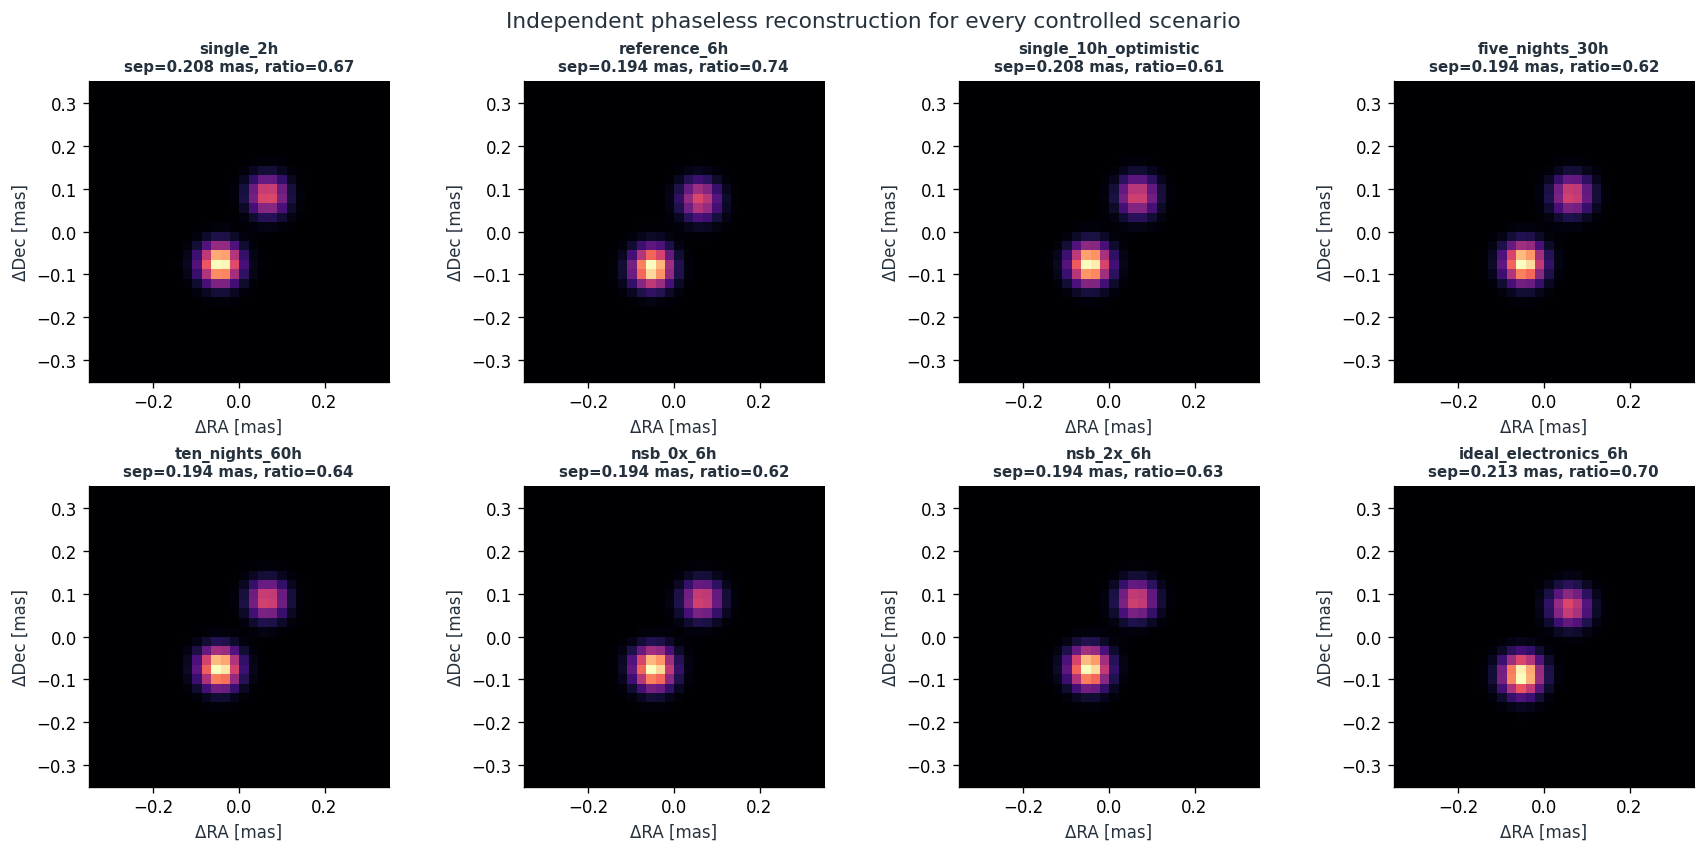

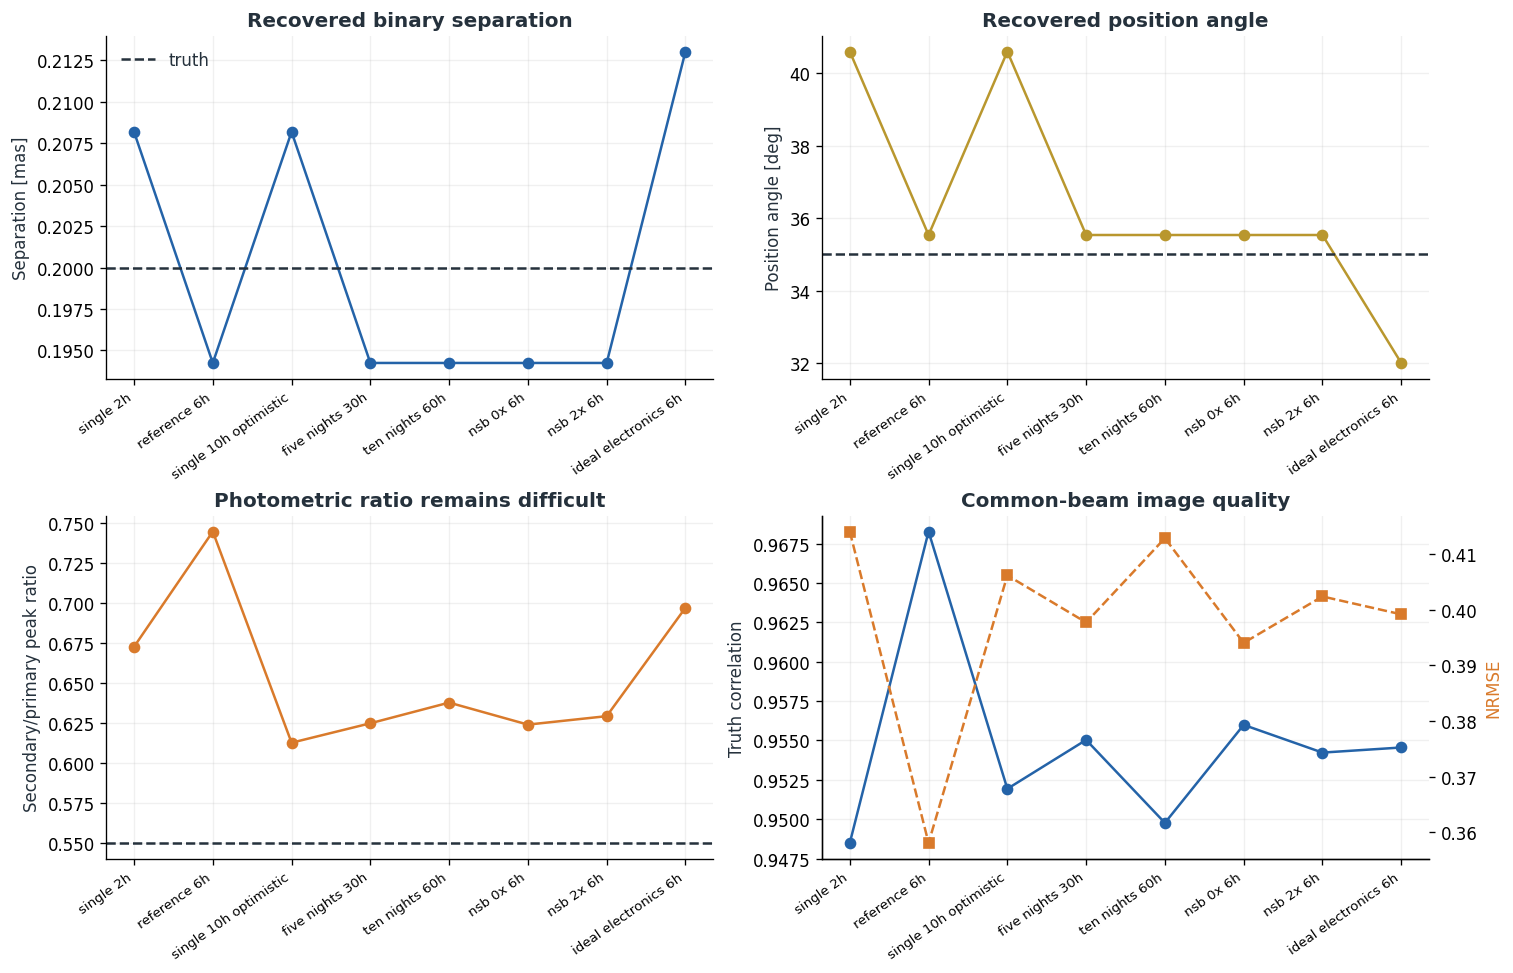

In [18]:
fig, axes = plt.subplots(2, 4, figsize=(14.5, 7.0), constrained_layout=True)
for axis, definition in zip(axes.ravel(), scenario_definitions):
    name = definition["name"]
    theta, image = scenario_images[name]
    row = scenario_table.loc[scenario_table.scenario==name].iloc[0]
    artist = axis.imshow(
        image, origin="lower",
        extent=[theta[0],theta[-1],theta[0],theta[-1]], cmap="magma")
    axis.set_title(
        f"{name}\nsep={row.recovered_separation_mas:.3f} mas, "
        f"ratio={row.recovered_peak_ratio:.2f}", fontsize=9)
    axis.set(xlabel="ΔRA [mas]", ylabel="ΔDec [mas]")
fig.suptitle("Independent phaseless reconstruction for every controlled scenario", fontsize=13)
fig.savefig(OUTPUT_DIR/"scenario_reconstruction_gallery.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.0), constrained_layout=True)
labels = scenario_table.scenario.str.replace("_", " ")
x = np.arange(len(scenario_table))
axes[0,0].plot(x, scenario_table.recovered_separation_mas, "o-", color=BLUE)
axes[0,0].axhline(SOURCE.separation_mas, color=INK, linestyle="--", label="truth")
axes[0,0].set(ylabel="Separation [mas]", title="Recovered binary separation")
axes[0,0].legend(frameon=False)
axes[0,1].plot(x, scenario_table.recovered_position_angle_deg, "o-", color=GOLD)
axes[0,1].axhline(SOURCE.position_angle_deg, color=INK, linestyle="--")
axes[0,1].set(ylabel="Position angle [deg]", title="Recovered position angle")
axes[1,0].plot(x, scenario_table.recovered_peak_ratio, "o-", color=ORANGE)
axes[1,0].axhline(SOURCE.flux_ratio_secondary_to_primary, color=INK, linestyle="--")
axes[1,0].set(ylabel="Secondary/primary peak ratio", title="Photometric ratio remains difficult")
axes[1,1].plot(x, scenario_table.common_beam_truth_correlation, "o-", color=BLUE, label="correlation")
ax_nrmse = axes[1,1].twinx()
ax_nrmse.plot(x, scenario_table.common_beam_truth_nrmse, "s--", color=ORANGE, label="NRMSE")
axes[1,1].set(ylabel="Truth correlation", title="Common-beam image quality")
ax_nrmse.set_ylabel("NRMSE", color=ORANGE)
for axis in axes.ravel():
    axis.set_xticks(x, labels, rotation=35, ha="right", fontsize=8)
    axis.grid(alpha=.18)
fig.savefig(OUTPUT_DIR/"scenario_reconstruction_metrics.png", bbox_inches="tight")
plt.show()

## 11. 望远镜级 Monte Carlo：共享误差、光子涨落与重建成功率

上面的单张图不能证明可靠性。本节固定天体真值，生成100次完全独立的6小时观测。每次实现都先为32台望远镜逐段生成恒星和NSB的 Poisson 总计数，再生成随时间相关的透明度/NSB过程、每镜静态与每夜增益残差、每镜时钟残差以及每条基线零点；同一台镜的同一份实现被它参与的31条基线共同使用。

100次均做带误差权重的双星参数拟合，用来快速量化分离、方位角和流量比的抽样分布。这里固定了两个星盘直径，因此它是“已知源族条件下”的参数精度，不等于盲成像能力。更暗目标的盲检验覆盖18个“星等×积分时间”组合：2小时、6小时、5夜30小时和10夜60小时，星等从 (m_{AB}=2) 到8（7、8等只在最长的60小时检验）；每个组合做30次双星注入和30次单星空白，共1080张盲图。优化器不知道源类型；只有“双星真阳性率高且单星假阳性率低”，才支持“看见两个结构”。预先固定的检出规则是峰间距0.10–0.32 mas且次/主峰比不低于0.25；比例同时给出 Clopper–Pearson 精确95%区间。一个星等/时长组合只有在真阳性率95%下限不低于80%、且假阳性率95%上限不高于20%时才标为“可靠检出”。当双星真阳性与单星假阳性的95%区间重叠时，额外标记为本样本量下“不可区分”；这比只看双星图是否出现两个峰更接近“看不到”的含义。

光子计数涨落没有被重复添加成任意的共享高斯噪声。对近零相关的不同基线，纯散粒噪声的交叉乘积协方差本来就极小；显著的跨基线相关主要来自望远镜级增益、时间和背景标定。本节分别保存了这些量，方便以后用实测稳定性替换当前工程假设。

,parameter,p2p5,median,p97p5,truth
0,separation_mas,0.199631,0.200015,0.200308,0.20
1,position_angle_deg,34.935429,35.003747,35.075860,35.00
2,flux_ratio,0.550134,0.559415,0.572607,0.55


,value
realizations,100
all_parametric_fits_converged,True
night_averaged_shared_telescope_error_correlation,0.084423
night_averaged_disjoint_baseline_error_correlation,-0.084129
median_per_telescope_segment_photon_relative_rms,0.000002
median_pair_timing_attenuation,0.991677


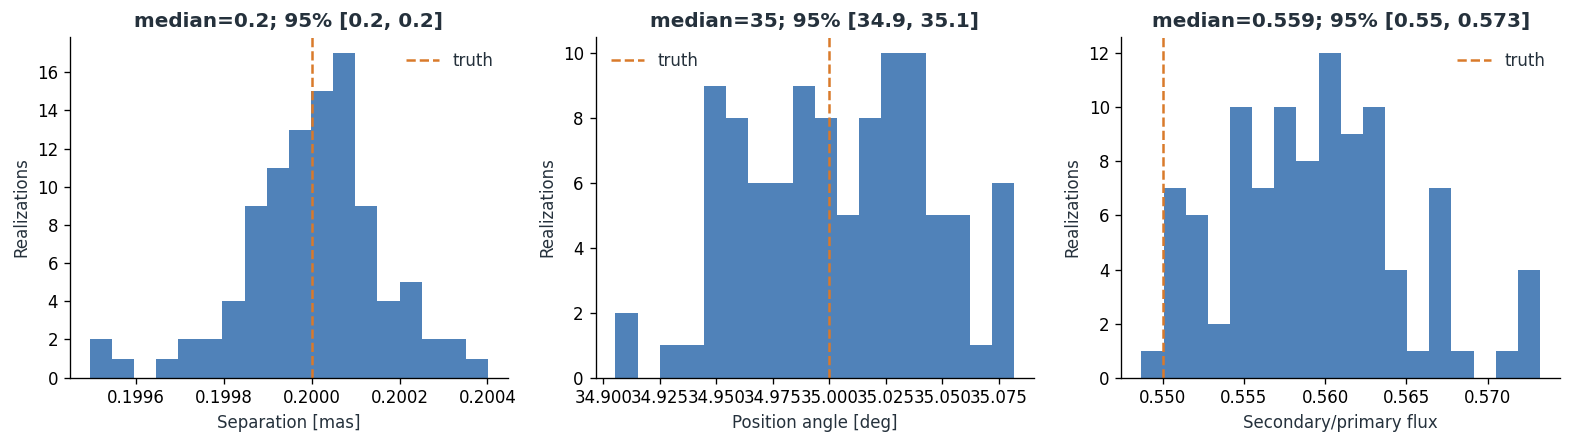

In [19]:
def fit_binary_parameters(frame):
    u = frame.u_lambda.to_numpy(float)
    v = frame.v_lambda.to_numpy(float)
    measured = frame.visibility2_measured.to_numpy(float)
    sigma = frame.sigma_visibility2.to_numpy(float)

    def residual(parameters):
        source = replace(
            SOURCE,
            separation_mas=parameters[0],
            position_angle_deg=parameters[1],
            flux_ratio_secondary_to_primary=parameters[2])
        model = np.abs(binary_visibility(u, v, source))**2
        return (measured-model)/sigma

    fit = least_squares(
        residual, x0=[0.18, 30.0, 0.45],
        bounds=([0.04, 0.0, 0.03], [0.40, 180.0, 1.0]),
        max_nfev=250)
    return fit.x, float(np.mean(residual(fit.x)**2)), bool(fit.success)

ensemble_rows = []
shared_error_probe = []
for realization in range(100):
    frame, metadata = make_scenario_measurements(
        6, 1, 1, "reference", 20263000+realization)
    fitted, reduced_chi2_proxy, fit_success = fit_binary_parameters(frame)
    ensemble_rows.append({
        "realization": realization,
        "separation_mas": fitted[0],
        "position_angle_deg": fitted[1],
        "flux_ratio": fitted[2],
        "reduced_chi2_proxy": reduced_chi2_proxy,
        "fit_success": fit_success,
        "median_photon_count_relative_rms": metadata[
            "median_photon_count_relative_rms"],
        "median_timing_attenuation": metadata["median_timing_attenuation"],
        "rms_pair_gain_error": metadata["rms_pair_gain_error"],
    })
    baseline_average = (
        frame.assign(error=frame.visibility2_measured-frame.visibility2_true)
        .groupby(["telescope_i", "telescope_j"], as_index=False).error.mean())
    # Rows 0/1 share telescope i; the final row is disjoint from row 0.
    # Averaging the 18 segments exposes the calibration covariance that is
    # otherwise hidden under much larger single-segment shot noise.
    shared_error_probe.append([
        baseline_average.loc[0, "error"],
        baseline_average.loc[1, "error"],
        baseline_average.iloc[-1].error,
    ])

ensemble_table = pd.DataFrame(ensemble_rows)
ensemble_table.to_csv(OUTPUT_DIR/"telescope_level_100_realizations.csv", index=False)
shared_error_probe = np.asarray(shared_error_probe)
shared_baseline_error_correlation = float(np.corrcoef(
    shared_error_probe[:,0], shared_error_probe[:,1])[0,1])
disjoint_baseline_error_correlation = float(np.corrcoef(
    shared_error_probe[:,0], shared_error_probe[:,2])[0,1])

def central_interval(values):
    return np.percentile(values, [2.5, 50.0, 97.5])

ensemble_summary = pd.DataFrame([
    ["separation_mas", *central_interval(ensemble_table.separation_mas), SOURCE.separation_mas],
    ["position_angle_deg", *central_interval(ensemble_table.position_angle_deg), SOURCE.position_angle_deg],
    ["flux_ratio", *central_interval(ensemble_table.flux_ratio), SOURCE.flux_ratio_secondary_to_primary],
], columns=["parameter", "p2p5", "median", "p97p5", "truth"])
display(ensemble_summary)
display(pd.DataFrame([{
    "realizations": len(ensemble_table),
    "all_parametric_fits_converged": bool(ensemble_table.fit_success.all()),
    "night_averaged_shared_telescope_error_correlation": shared_baseline_error_correlation,
    "night_averaged_disjoint_baseline_error_correlation": disjoint_baseline_error_correlation,
    "median_per_telescope_segment_photon_relative_rms": float(
        ensemble_table.median_photon_count_relative_rms.median()),
    "median_pair_timing_attenuation": float(
        ensemble_table.median_timing_attenuation.median()),
}]).T.rename(columns={0:"value"}))

fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.8))
for axis, column, truth, label in zip(
        axes,
        ["separation_mas", "position_angle_deg", "flux_ratio"],
        [SOURCE.separation_mas, SOURCE.position_angle_deg,
         SOURCE.flux_ratio_secondary_to_primary],
        ["Separation [mas]", "Position angle [deg]", "Secondary/primary flux"]):
    axis.hist(ensemble_table[column], bins=18, color=BLUE, alpha=.8)
    axis.axvline(truth, color=ORANGE, linestyle="--", label="truth")
    interval = central_interval(ensemble_table[column])
    axis.set(title=f"median={interval[1]:.3g}; 95% [{interval[0]:.3g}, {interval[2]:.3g}]",
             xlabel=label, ylabel="Realizations")
    axis.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR/"telescope_level_parameter_ensemble.png", bbox_inches="tight")
plt.show()

,single_night_hours,nights,total_integration_hours,source_ab_magnitude,source_case,realizations,detections,detection_rate,ci95_low,ci95_high,median_separation_mas,median_peak_ratio
0,2,1,2,2,binary,30,30,1.0000,0.8843,1.0000,0.2230,0.5461
1,2,1,2,2,single_disk,30,0,0.0000,0.0000,0.1157,0.1198,0.0000
2,2,1,2,3,binary,30,30,1.0000,0.8843,1.0000,0.2090,0.5669
3,2,1,2,3,single_disk,30,0,0.0000,0.0000,0.1157,0.1278,0.0000
4,2,1,2,4,binary,30,30,1.0000,0.8843,1.0000,0.2025,0.6362
5,2,1,2,4,single_disk,30,0,0.0000,0.0000,0.1157,0.1518,0.0000
6,2,1,2,5,binary,30,27,0.9000,0.7347,0.9789,0.2024,0.8447
7,2,1,2,5,single_disk,30,16,0.5333,0.3433,0.7166,0.1870,0.2892
8,6,1,6,2,binary,30,30,1.0000,0.8843,1.0000,0.2230,0.5465
9,6,1,6,2,single_disk,30,0,0.0000,0.0000,0.1157,0.1159,0.0000


,single_night_hours,nights,total_integration_hours,source_ab_magnitude,true_positive_rate,true_positive_ci95_low,true_positive_ci95_high,false_positive_rate,false_positive_ci95_low,false_positive_ci95_high,discrimination_advantage,binary_null_ci95_overlap,reliable_detection
0,2,1,2,2,1.0000,0.8843,1.0000,0.0000,0.0000,0.1157,1.0000,False,True
1,2,1,2,3,1.0000,0.8843,1.0000,0.0000,0.0000,0.1157,1.0000,False,True
2,2,1,2,4,1.0000,0.8843,1.0000,0.0000,0.0000,0.1157,1.0000,False,True
3,2,1,2,5,0.9000,0.7347,0.9789,0.5333,0.3433,0.7166,0.3667,False,False
4,6,1,6,2,1.0000,0.8843,1.0000,0.0000,0.0000,0.1157,1.0000,False,True
5,6,1,6,3,1.0000,0.8843,1.0000,0.0000,0.0000,0.1157,1.0000,False,True
6,6,1,6,4,1.0000,0.8843,1.0000,0.0000,0.0000,0.1157,1.0000,False,True
7,6,1,6,5,0.9667,0.8278,0.9992,0.1333,0.0376,0.3072,0.8333,False,False
8,6,1,6,6,0.7667,0.5772,0.9007,0.8333,0.6528,0.9436,-0.0667,True,False
9,6,5,30,3,1.0000,0.8843,1.0000,0.0000,0.0000,0.1157,1.0000,False,True


**最长60 h从可靠、失去可靠性到不可区分的转折：** 下表的 `binary_null_ci95_overlap=True` 表示双星注入与单星空白的检出率95%区间重叠；此时不能声称数据能区分双星。

,source_ab_magnitude,true_positive_rate,true_positive_ci95_low,true_positive_ci95_high,false_positive_rate,false_positive_ci95_low,false_positive_ci95_high,discrimination_advantage,binary_null_ci95_overlap,reliable_detection
13,4,1.0000,0.8843,1.0000,0.0,0.000,0.1157,1.0000,False,True
14,5,1.0000,0.8843,1.0000,0.0,0.000,0.1157,1.0000,False,True
15,6,0.9000,0.7347,0.9789,0.5,0.313,0.6870,0.4000,False,False
16,7,0.7333,0.5411,0.8772,0.7,0.506,0.8527,0.0333,True,False
17,8,0.7667,0.5772,0.9007,0.7,0.506,0.8527,0.0667,True,False


,total_integration_hours,faintest_reliable_magnitude_tested
0,2,4
1,6,4
2,30,5
3,60,5


**按预先声明的可靠性标准，本次离散网格中最暗的可靠双星检出为：** 2 h → m_AB=4；6 h → m_AB=4；30 h → m_AB=5；60 h → m_AB=5。这些是已测试网格点，不是在相邻星等之间插值得到的连续极限。

separation_mas  \
total_integration_hours source_ab_magnitude quantile                   
2                       2                   0.025             0.2025   
                                            0.500             0.2230   
                                            0.975             0.2230   
                        3                   0.025             0.1870   
                                            0.500             0.2090   
                                            0.975             0.2230   
                        4                   0.025             0.1870   
                                            0.500             0.2025   
                                            0.975             0.2230   
                        5                   0.025             0.1091   
                                            0.500             0.2024   
                                            0.975             0.3718   
6                       2                   0.025             0.1870   
                                            0.500             0.2230   
                                            0.975             0.2230   
                        3                   0.025             0.1870   
                                            0.500             0.2090   
                                            0.975             0.2230   
                        4                   0.025             0.1870   
                                            0.500             0.2025   
                                            0.975             0.2230   
                        5                   0.025             0.1717   
                                            0.500             0.2025   
                                            0.975             0.3094   
                        6                   0.025             0.1037   
                                            0.500             0.1931   
                                            0.975             0.4211   
30                      3                   0.025             0.1870   
                                            0.500             0.2090   
                                            0.975             0.2230   
                        4                   0.025             0.1870   
                                            0.500             0.2230   
                                            0.975             0.2230   
                        5                   0.025             0.1870   
                                            0.500             0.2025   
                                            0.975             0.2230   
                        6                   0.025             0.1091   
                                            0.500             0.1974   
                                            0.975             0.3886   
60                      4                   0.025             0.1870   
                                            0.500             0.2090   
                                            0.975             0.2230   
                        5                   0.025             0.1870   
                                            0.500             0.2025   
                                            0.975             0.2230   
                        6                   0.025             0.1083   
                                            0.500             0.2090   
                                            0.975             0.3285   
                        7                   0.025             0.1037   
                                            0.500             0.2145   
                                            0.975             0.4051   
                        8                   0.025             0.1069   
                                            0.500             0.2223   
                                            0.975             0.3995   

                     

realizations  \
single_night_hours nights total_integration_hours source_ab_magnitude source_case                 
2                  1      2                       2                   binary                 30   
                                                                      single_disk            30   
                                                  3                   binary                 30   
                                                                      single_disk            30   
                                                  4                   binary                 30   
                                                                      single_disk            30   
                                                  5                   binary                 30   
                                                                      single_disk            30   
6                  1      6                       2                   binary                 30   
                                                                      single_disk            30   
                                                  3                   binary                 30   
                                                                      single_disk            30   
                                                  4                   binary                 30   
                                                                      single_disk            30   
                                                  5                   binary                 30   
                                                                      single_disk            30   
                                                  6                   binary                 30   
                                                                      single_disk            30   
                   5      30                      3                   binary                 30   
                                                                      single_disk            30   
                                                  4                   binary                 30   
                                                                      single_disk            30   
                                                  5                   binary                 30   
                                                                      single_disk            30   
                                                  6                   binary                 30   
                                                                      single_disk            30   
                   10     60                      4                   binary                 30   
                                                                      single_disk            30   
                                                  5                   binary                 30   
                                                                      single_disk            30   
                                                  6                   binary                 30   
                                                                      single_disk            30   
                                                  7                   binary                 30   
                                                                      single_disk            30   
                                                  8                   binary                 30   
                                                                      single_disk            30   

                                                                                   detections  \
single_night_hours nights total_integration_hours source_ab_magnitude source_case               
2                  1      2                       2                   binary               30   
                             

,realization,single_night_hours,nights,total_integration_hours,source_ab_magnitude,source_case,two_peak_detection,separation_mas,position_angle_deg,peak_ratio,weighted_forward_rmse
0,0,2,1,2,2,binary,True,0.2025,39.8056,0.5648,0.0541
1,0,2,1,2,2,single_disk,False,0.2090,60.2551,0.0000,0.0526
2,1,2,1,2,2,binary,True,0.2230,35.5377,0.5130,0.0549
3,1,2,1,2,2,single_disk,False,0.1037,0.0000,0.0000,0.0527
4,2,2,1,2,2,binary,True,0.2230,35.5377,0.5511,0.0568
5,2,2,1,2,2,single_disk,False,0.2215,159.4440,0.0000,0.0548
6,3,2,1,2,2,binary,True,0.2090,29.7449,0.5079,0.0563
7,3,2,1,2,2,single_disk,False,0.1100,45.0000,0.0000,0.0548
8,4,2,1,2,2,binary,True,0.2230,35.5377,0.7927,0.0539
9,4,2,1,2,2,single_disk,False,0.1037,90.0000,0.0000,0.0529


mAB=2, 2 h binary: 100.0% (95% 88.4%–100.0%)
mAB=2, 2 h single_disk: 0.0% (95% 0.0%–11.6%)
mAB=3, 2 h binary: 100.0% (95% 88.4%–100.0%)
mAB=3, 2 h single_disk: 0.0% (95% 0.0%–11.6%)
mAB=4, 2 h binary: 100.0% (95% 88.4%–100.0%)
mAB=4, 2 h single_disk: 0.0% (95% 0.0%–11.6%)
mAB=5, 2 h binary: 90.0% (95% 73.5%–97.9%)
mAB=5, 2 h single_disk: 53.3% (95% 34.3%–71.7%)
mAB=2, 6 h binary: 100.0% (95% 88.4%–100.0%)
mAB=2, 6 h single_disk: 0.0% (95% 0.0%–11.6%)
mAB=3, 6 h binary: 100.0% (95% 88.4%–100.0%)
mAB=3, 6 h single_disk: 0.0% (95% 0.0%–11.6%)
mAB=4, 6 h binary: 100.0% (95% 88.4%–100.0%)
mAB=4, 6 h single_disk: 0.0% (95% 0.0%–11.6%)
mAB=5, 6 h binary: 96.7% (95% 82.8%–99.9%)
mAB=5, 6 h single_disk: 13.3% (95% 3.8%–30.7%)
mAB=6, 6 h binary: 76.7% (95% 57.7%–90.1%)
mAB=6, 6 h single_disk: 83.3% (95% 65.3%–94.4%)
mAB=3, 30 h binary: 100.0% (95% 88.4%–100.0%)
mAB=3, 30 h single_disk: 0.0% (95% 0.0%–11.6%)
mAB=4, 30 h binary: 100.0% (95% 88.4%–100.0%)
mAB=4, 30 h single_disk: 0.0% (95% 0.0%–11.

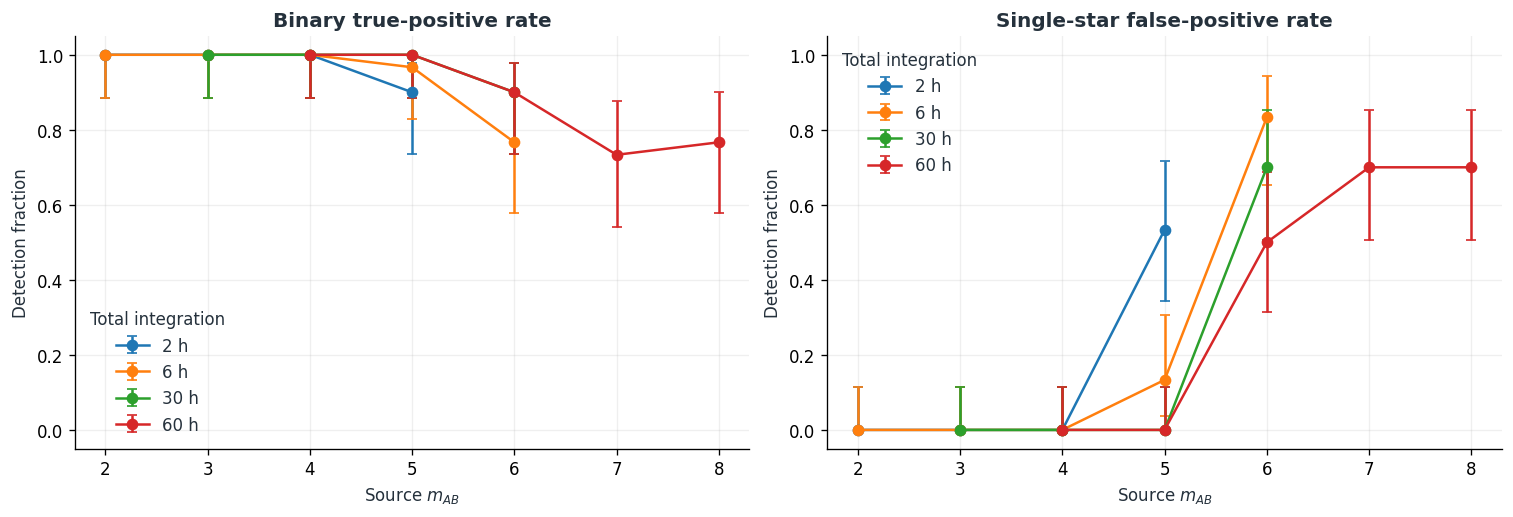

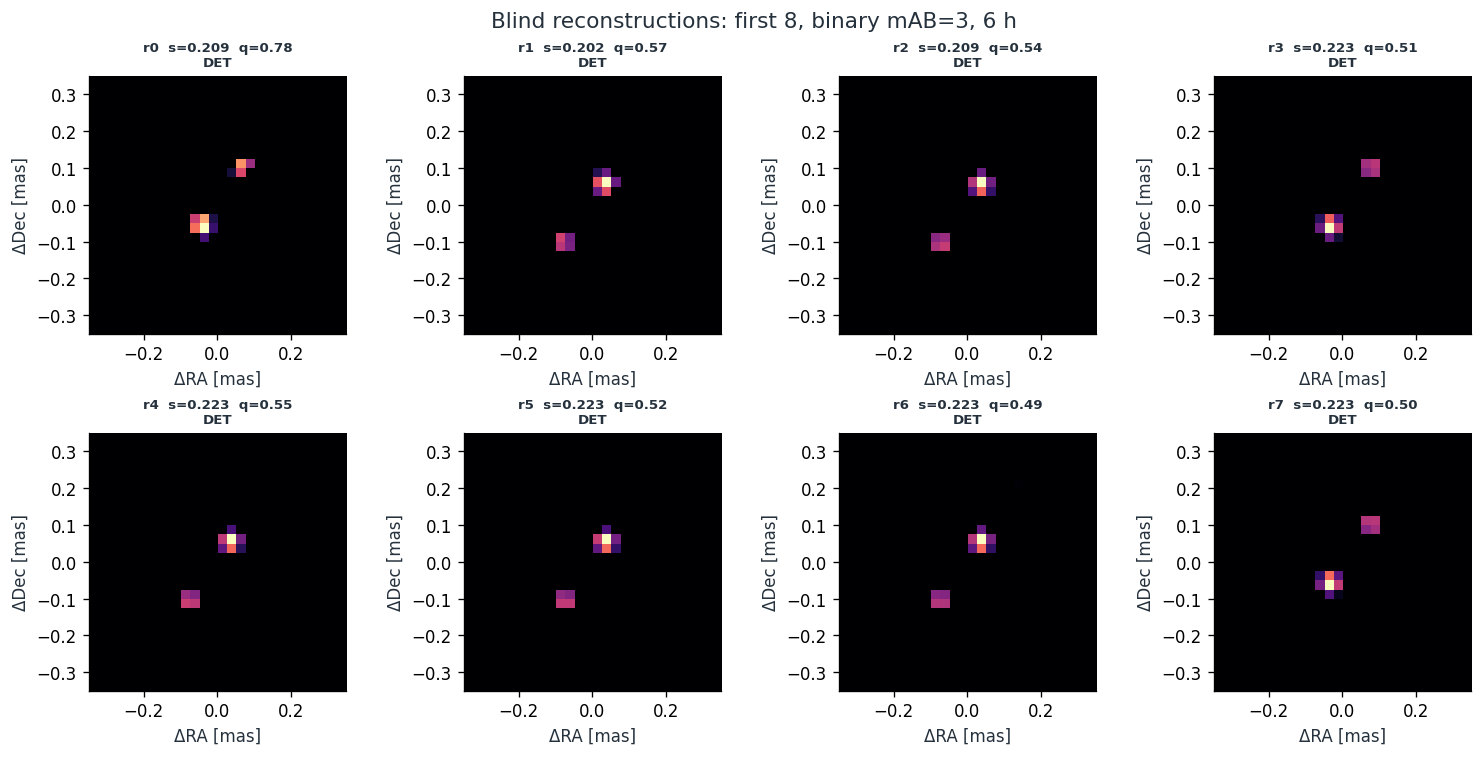

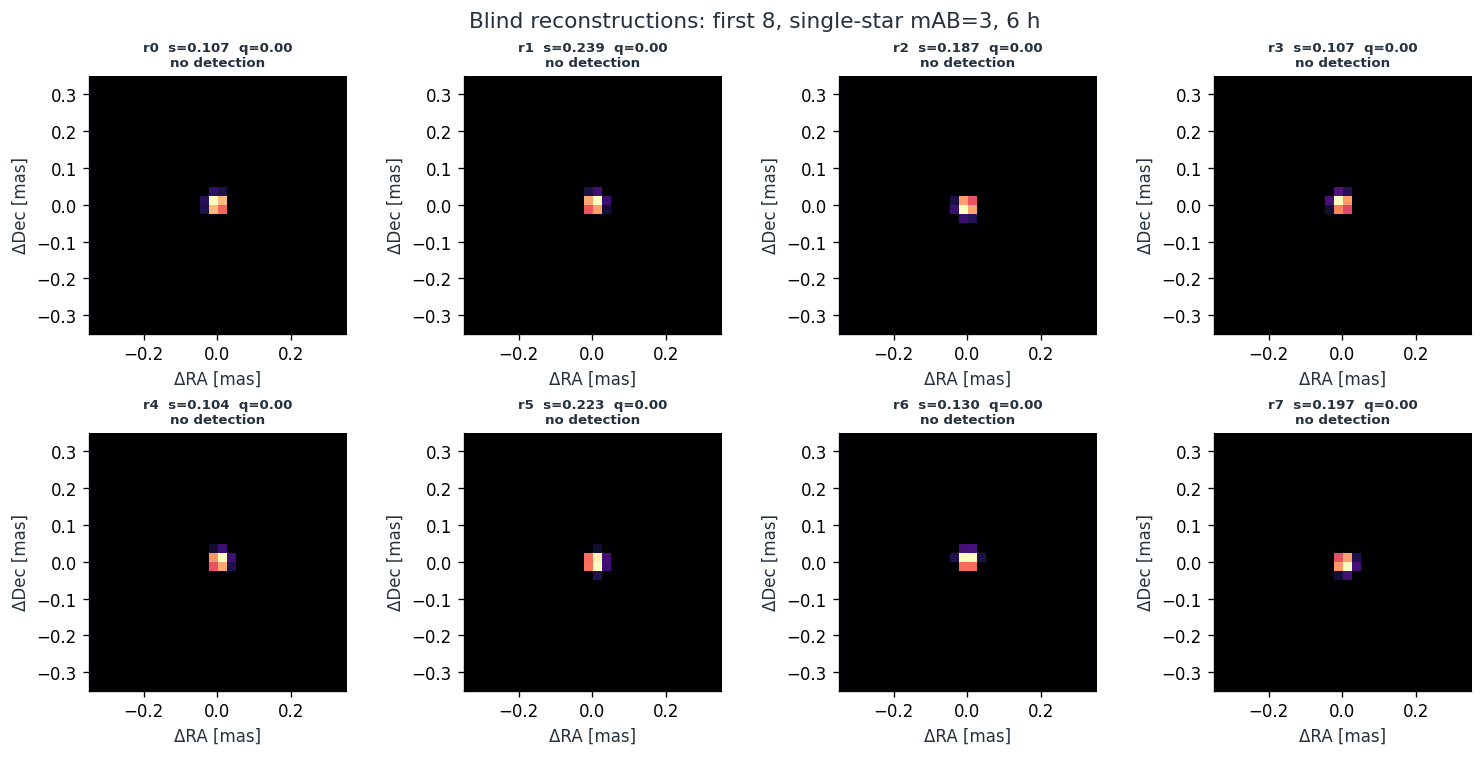

In [20]:
nonparametric_rows = []
nonparametric_images = {}

def reconstruct_blind_case(single_night_hours, nights, magnitude,
                           realization, source_case, frame):
    data = scenario_uv_data(frame)
    reconstruction = reconstruct_uv_data(
        data, grid_size=28, fov_mas=0.70, support_radius_mas=0.32,
        starts=3, max_iter=650, smoothness=0.020,
        huber_delta=0.15,
        seed=(20264000 + int(10000*magnitude)
              + 1000*single_night_hours + 10*nights + realization),
        peak_minimum_separation_mas=0.10)
    separation = reconstruction.metrics.get("two_peak_separation_mas", np.nan)
    angle = reconstruction.metrics.get("two_peak_position_angle_deg", np.nan)
    ratio = reconstruction.metrics.get("two_peak_brightness_ratio", np.nan)
    # Pre-declared structural detection rule. Peak finding always returns
    # two candidates, so separation alone is not a valid detection.
    detected = bool(
        np.isfinite(separation) and np.isfinite(ratio)
        and 0.10 <= separation <= 0.32 and ratio >= 0.25)
    row = {
        "realization": realization,
        "single_night_hours": single_night_hours,
        "nights": nights,
        "total_integration_hours": single_night_hours*nights,
        "source_ab_magnitude": magnitude,
        "source_case": source_case,
        "two_peak_detection": detected,
        "separation_mas": separation,
        "position_angle_deg": angle,
        "peak_ratio": ratio,
        "weighted_forward_rmse": reconstruction.metrics["weighted_fit_rmse"],
    }
    nonparametric_rows.append(row)
    nonparametric_images[(single_night_hours, nights, magnitude,
                          source_case, realization)] = (
        reconstruction.theta_mas, reconstruction.image)
    return row

blind_scenarios = [
    {"single_night_hours":2, "nights":1, "magnitudes":[2,3,4,5]},
    {"single_night_hours":6, "nights":1, "magnitudes":[2,3,4,5,6]},
    {"single_night_hours":6, "nights":5, "magnitudes":[3,4,5,6]},
    {"single_night_hours":6, "nights":10, "magnitudes":[4,5,6,7,8]},
]
blind_realizations_per_case = 30
for blind_definition in blind_scenarios:
    single_night_hours = blind_definition["single_night_hours"]
    nights = blind_definition["nights"]
    for magnitude in blind_definition["magnitudes"]:
        for realization in range(blind_realizations_per_case):
            measurement_seed = (
                20263000 + int(10000*magnitude)
                + 1000*single_night_hours + 10*nights + realization)
            binary_frame, _ = make_scenario_measurements(
                single_night_hours, nights, 1, "reference",
                measurement_seed, source_case="binary",
                source_ab_magnitude=magnitude)
            reconstruct_blind_case(
                single_night_hours, nights, magnitude, realization,
                "binary", binary_frame)
            null_frame, _ = make_scenario_measurements(
                single_night_hours, nights, 1, "reference",
                measurement_seed, source_case="single_disk",
                source_ab_magnitude=magnitude)
            reconstruct_blind_case(
                single_night_hours, nights, magnitude, realization,
                "single_disk", null_frame)

nonparametric_table = pd.DataFrame(nonparametric_rows)
nonparametric_binary_table = nonparametric_table.loc[
    nonparametric_table.source_case == "binary"].copy()
nonparametric_null_table = nonparametric_table.loc[
    nonparametric_table.source_case == "single_disk"].copy()
nonparametric_table.to_csv(
    OUTPUT_DIR/"faint_magnitude_1080_binary_and_null_controls.csv", index=False)
def clopper_pearson(successes, trials, alpha=0.05):
    lower = 0.0 if successes == 0 else beta.ppf(
        alpha/2, successes, trials-successes+1)
    upper = 1.0 if successes == trials else beta.ppf(
        1-alpha/2, successes+1, trials-successes)
    return float(lower), float(upper)
detection_rows = []
detection_group_columns = [
    "single_night_hours", "nights", "total_integration_hours",
    "source_ab_magnitude", "source_case"]
for group_key, group in nonparametric_table.groupby(
        detection_group_columns):
    single_night_hours, nights, total_hours, magnitude, source_case = group_key
    successes = int(group.two_peak_detection.sum())
    interval = clopper_pearson(successes, len(group))
    detection_rows.append({
        "single_night_hours": single_night_hours,
        "nights": nights,
        "total_integration_hours": total_hours,
        "source_ab_magnitude": magnitude,
        "source_case": source_case,
        "realizations": len(group), "detections": successes,
        "detection_rate": successes/len(group),
        "ci95_low": interval[0], "ci95_high": interval[1],
        "median_separation_mas": group.separation_mas.median(),
        "median_peak_ratio": group.peak_ratio.median(),
    })
detection_summary = pd.DataFrame(detection_rows)
display(detection_summary.round(4))
scenario_key_columns = [
    "single_night_hours", "nights", "total_integration_hours",
    "source_ab_magnitude"]
true_positive = detection_summary.loc[
    detection_summary.source_case == "binary"].rename(columns={
        "detection_rate":"true_positive_rate",
        "ci95_low":"true_positive_ci95_low",
        "ci95_high":"true_positive_ci95_high",
    })[scenario_key_columns + [
        "true_positive_rate", "true_positive_ci95_low",
        "true_positive_ci95_high"]]
false_positive = detection_summary.loc[
    detection_summary.source_case == "single_disk"].rename(columns={
        "detection_rate":"false_positive_rate",
        "ci95_low":"false_positive_ci95_low",
        "ci95_high":"false_positive_ci95_high",
    })[scenario_key_columns + [
        "false_positive_rate", "false_positive_ci95_low",
        "false_positive_ci95_high"]]
performance_summary = true_positive.merge(false_positive,
                                           on=scenario_key_columns)
performance_summary["discrimination_advantage"] = (
    performance_summary.true_positive_rate
    - performance_summary.false_positive_rate)
performance_summary["binary_null_ci95_overlap"] = (
    (performance_summary.true_positive_ci95_low
     <= performance_summary.false_positive_ci95_high)
    & (performance_summary.false_positive_ci95_low
       <= performance_summary.true_positive_ci95_high))
performance_summary["reliable_detection"] = (
    (performance_summary.true_positive_ci95_low >= 0.80)
    & (performance_summary.false_positive_ci95_high <= 0.20))
limiting_magnitude_empirical = (
    performance_summary.loc[performance_summary.reliable_detection]
    .groupby("total_integration_hours", as_index=False)
    .source_ab_magnitude.max()
    .rename(columns={"source_ab_magnitude":"faintest_reliable_magnitude_tested"}))
display(performance_summary.round(4))
display(Markdown(
    "**最长60 h从可靠、失去可靠性到不可区分的转折：** "
    "下表的 `binary_null_ci95_overlap=True` 表示双星注入与单星空白的"
    "检出率95%区间重叠；此时不能声称数据能区分双星。"))
display(performance_summary.loc[
    performance_summary.total_integration_hours == 60, [
        "source_ab_magnitude", "true_positive_rate",
        "true_positive_ci95_low", "true_positive_ci95_high",
        "false_positive_rate", "false_positive_ci95_low",
        "false_positive_ci95_high", "discrimination_advantage",
        "binary_null_ci95_overlap", "reliable_detection"]].round(4))
display(limiting_magnitude_empirical)
display(Markdown(
    "**按预先声明的可靠性标准，本次离散网格中最暗的可靠双星检出为：** "
    + "；".join(
        f"{row.total_integration_hours:g} h → m_AB={row.faintest_reliable_magnitude_tested:g}"
        for row in limiting_magnitude_empirical.itertuples())
    + "。这些是已测试网格点，不是在相邻星等之间插值得到的连续极限。"))
binary_recovery_intervals = (
    nonparametric_binary_table.groupby(
        ["total_integration_hours", "source_ab_magnitude"])[[
        "separation_mas", "position_angle_deg", "peak_ratio",
        "weighted_forward_rmse"]]
    .quantile([0.025, 0.5, 0.975])
    .rename_axis(index=["total_integration_hours", "source_ab_magnitude",
                        "quantile"]))
display(binary_recovery_intervals.round(4))
display(nonparametric_table.groupby(detection_group_columns).agg(
    realizations=("realization", "size"),
    detections=("two_peak_detection", "sum"),
    detection_rate=("two_peak_detection", "mean"),
    median_separation_mas=("separation_mas", "median"),
    median_peak_ratio=("peak_ratio", "median"),
    median_forward_rmse=("weighted_forward_rmse", "median"),
).round(4))
display(nonparametric_table.head(12).round(4))
for row in detection_rows:
    print(
        f"mAB={row['source_ab_magnitude']:g}, "
        f"{row['total_integration_hours']:g} h {row['source_case']}: "
        f"{row['detection_rate']:.1%} "
        f"(95% {row['ci95_low']:.1%}–{row['ci95_high']:.1%})")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), constrained_layout=True)
for axis, source_case, title in zip(
        axes, ["binary", "single_disk"],
        ["Binary true-positive rate", "Single-star false-positive rate"]):
    subset = detection_summary.loc[detection_summary.source_case == source_case]
    for total_hours, group in subset.groupby("total_integration_hours"):
        group = group.sort_values("source_ab_magnitude")
        axis.errorbar(
            group.source_ab_magnitude, group.detection_rate,
            yerr=[group.detection_rate-group.ci95_low,
                  group.ci95_high-group.detection_rate],
            marker="o", capsize=3, label=f"{total_hours:g} h")
    axis.set(title=title, xlabel=r"Source $m_{AB}$",
             ylabel="Detection fraction", ylim=(-0.05, 1.05))
    axis.grid(alpha=.2)
    axis.legend(frameon=False, title="Total integration")
fig.savefig(OUTPUT_DIR/"faint_magnitude_detection_efficiency.png",
            bbox_inches="tight")
plt.show()

def plot_blind_gallery(single_night_hours, nights, magnitude,
                       source_case, table, filename, title):
    fig, axes = plt.subplots(2, 4, figsize=(12.5, 6.2), constrained_layout=True)
    for axis, (_, row) in zip(axes.ravel(), table.head(8).iterrows()):
        theta, image = nonparametric_images[
            (single_night_hours, nights, magnitude,
             source_case, int(row.realization))]
        axis.imshow(image, origin="lower",
                    extent=[theta[0],theta[-1],theta[0],theta[-1]], cmap="magma")
        axis.set_title(
            f"r{int(row.realization)}  s={row.separation_mas:.3f}  "
            f"q={row.peak_ratio:.2f}\n"
            f"{'DET' if row.two_peak_detection else 'no detection'}",
            fontsize=8)
        axis.set(xlabel="ΔRA [mas]", ylabel="ΔDec [mas]")
    fig.suptitle(title, fontsize=13)
    fig.savefig(OUTPUT_DIR/filename, bbox_inches="tight")
    plt.show()

plot_blind_gallery(
    6, 1, 3, "binary", nonparametric_binary_table.loc[
        (nonparametric_binary_table.single_night_hours == 6)
        & (nonparametric_binary_table.nights == 1)
        & (nonparametric_binary_table.source_ab_magnitude == 3)],
    "faint_m3_6h_binary_first8.png",
    "Blind reconstructions: first 8, binary mAB=3, 6 h")
plot_blind_gallery(
    6, 1, 3, "single_disk", nonparametric_null_table.loc[
        (nonparametric_null_table.single_night_hours == 6)
        & (nonparametric_null_table.nights == 1)
        & (nonparametric_null_table.source_ab_magnitude == 3)],
    "faint_m3_6h_single_star_first8.png",
    "Blind reconstructions: first 8, single-star mAB=3, 6 h")

## 12. Checks

下列检查是本 notebook 的最低物理闭合门槛：

- (V(0,0)=1) 且 (|V(u,v)|^2=|V(-u,-v)|^2)；
- 32 镜编号连续、无重复，且 NWU→ENU 坐标转换逐行一致；
- 每条基线旋转后满足 (u^2+v^2+w^2=|\mathbf B|^2)；
- 5 星等的光子率严格为 0 星等的 1%；
- SNR 对积分时间按 (sqrt T) 缩放；
- 重建只用观测功率，前向闭合 RMSE 有界，并能在固有歧义下恢复双源结构。

In [21]:
checks = {}
checks["layout_has_32_unique_telescopes"] = (
    len(LACT32) == 32 and LACT32.telescope_id.is_unique and LACT32.lactsim_index.is_unique
)
checks["layout_nwu_to_enu_transform"] = (
    np.allclose(LACT32.east_m, -LACT32.corsika_west_cm/100.0)
    and np.allclose(LACT32.north_m, LACT32.corsika_north_cm/100.0)
    and np.allclose(LACT32.up_m, LACT32.corsika_up_cm/100.0)
)
checks["zero_baseline_visibility"] = np.isclose(abs(binary_visibility(0,0))**2,1,atol=1e-12)
probe_u = RNG.normal(0,1e9,100)
probe_v = RNG.normal(0,1e9,100)
checks["power_conjugate_symmetry"] = np.allclose(
    np.abs(binary_visibility(probe_u,probe_v))**2,
    np.abs(binary_visibility(-probe_u,-probe_v))**2,atol=1e-12)
checks["uvw_norm_invariant"] = invariant_error < 1e-6
checks["five_mag_rate_ratio"] = np.isclose(detected_star_rate_hz(5)/detected_star_rate_hz(0),0.01,rtol=1e-12)
checks["snr_sqrt_time"] = np.isclose(
    unit_visibility_snr(2,3600)/unit_visibility_snr(2,900),2.0,rtol=1e-12)
checks["short_waveform_has_expected_samples"] = len(short_record["sample_time_ns"]) == 1250
checks["short_waveform_has_full_spe_edge_padding"] = (
    short_record["simulated_padding_each_side_ns"] >= np.max(np.abs(spe_t_ns))
)
checks["six_hours_has_exactly_18_twenty_minute_segments"] = (
    len(hour_angles_h) == 18 and len(uv_coverage) == 18*len(lact_baselines)
)
checks["ray_traced_optical_timing_is_applied"] = (
    0.5 < optical_timing["rms_spread_ns"] < 0.7
    and 0.0 < optical_timing_efficiency < 1.0
    and short_record["optical_timing_rms_ns"] > 0.0
)
checks["recovery_loss_is_tiny_at_reference_rate"] = (
    recovery_table.analytic_mean_charge_fraction.min() > 0.9999
)
checks["empirical_charge_sample_is_mean_one"] = (
    len(empirical_charge_factors) == 537
    and np.isclose(np.mean(empirical_charge_factors), 1.0, atol=1e-14)
)
checks["all_controlled_scenarios_reconstructed"] = (
    len(scenario_table) == len(scenario_definitions) == 8
    and scenario_table.recovered_separation_mas.notna().all()
)
scenario_indexed = scenario_table.set_index("scenario")
checks["repeated_nights_reduce_statistical_sigma"] = (
    scenario_indexed.loc["ten_nights_60h", "sigma_visibility2_stat"]
    < scenario_indexed.loc["five_nights_30h", "sigma_visibility2_stat"]
    < scenario_indexed.loc["reference_6h", "sigma_visibility2_stat"]
)
checks["nsb_degrades_statistical_sigma"] = (
    scenario_indexed.loc["nsb_0x_6h", "sigma_visibility2_stat"]
    < scenario_indexed.loc["reference_6h", "sigma_visibility2_stat"]
    < scenario_indexed.loc["nsb_2x_6h", "sigma_visibility2_stat"]
)
checks["ideal_electronics_improves_statistical_sigma"] = (
    scenario_indexed.loc["ideal_electronics_6h", "sigma_visibility2_stat"]
    < scenario_indexed.loc["reference_6h", "sigma_visibility2_stat"]
)
checks["ten_hour_case_is_flagged_low_altitude"] = (
    scenario_indexed.loc["single_10h_optimistic", "minimum_altitude_deg"] < 30.0
)
checks["reconstruction_forward_closure"] = result.metrics["weighted_fit_rmse"] < 0.12
checks["reconstruction_recovers_two_peaks"] = len(result.metrics.get("peaks",[])) == 2
checks["truth_validation_correlation"] = truth_corr > 0.55
checks["telescope_level_ensemble_completed"] = (
    len(ensemble_table) == 100 and ensemble_table.fit_success.all()
)
checks["blind_nonparametric_ensemble_completed"] = (
    len(nonparametric_table) == 1080
    and len(nonparametric_binary_table) == 540
    and len(nonparametric_null_table) == 540
    and nonparametric_table.groupby(
        detection_group_columns).size().eq(30).all()
    and nonparametric_table.groupby(
        detection_group_columns).ngroups == 36
    and nonparametric_table.weighted_forward_rmse.notna().all()
)
validation = pd.DataFrame({"check":checks.keys(),"passed":checks.values()})
display(validation)
assert all(checks.values()), checks
validation.to_csv(OUTPUT_DIR/"validation_checks.csv",index=False)
print("ALL CHECKS PASSED")

,check,passed
0,layout_has_32_unique_telescopes,True
1,layout_nwu_to_enu_transform,True
2,zero_baseline_visibility,True
3,power_conjugate_symmetry,True
4,uvw_norm_invariant,True
5,five_mag_rate_ratio,True
6,snr_sqrt_time,True
7,short_waveform_has_expected_samples,True
8,short_waveform_has_full_spe_edge_padding,True
9,six_hours_has_exactly_18_twenty_minute_segments,True


ALL CHECKS PASSED


## 13. Takeaways & required caveats

1. 统一版以最新 `main` 为底座，保留旧 v1 的全阵列源/相干/重建框架，并吸收旧 v2 的连续电子学时间尺度；旧 v2 把 ENU 坐标直接代入缺少站点纬度的矩阵，统一版已经用 topocentric ENU 投影替换。
2. 7 镜验证阵列适合标定和直径测量；`layout_0803` 的 32 镜实际模拟坐标提供公里级基线，进入约 (0.1\,\mathrm{mas}) 及以下的成像区间。表中有物理最长基线和本次时角/赤纬的投影覆盖；它仍是生产输入坐标，不应冒充最终现场测绘值。
3. 正式1229分片镜面的轴上光追给出约0.602 ns RMS、1.732 ns峰峰值到达时间展宽；在假设的200 MHz矩形相关带宽内，只保留约 `optical_timing_efficiency` 所示比例的零延迟相关信号。notebook 已在短波形中逐 p.e. 抽样该分布，并在长曝光误差中按标定反演传播。
4. 受控情景显示：多夜累计降低统计误差，NSB增加恶化统计误差；10 h 单夜窗口端高度低，未加入高度相关消光前不能当作可信增益。现在每次实现使用严格的20分钟段中点，不再把观测端点误算成额外积分段。
5. (|V|^2) 成像天然缺相位。100次望远镜级参数拟合给出亮目标的抽样区间；1080张盲重建给出 (m_{AB}=2–8)、2–60小时条件下的真阳性率、单星假阳性率及精确95%区间，并检查两类区间是否已经重叠，从而直接定位“可靠”“不可靠”和“不可区分”的转折。单张“好看”的重建不再作为性能证据。参数拟合固定了星盘直径，仍比完全未知天体乐观。
6. 微单元恢复10 ns仍是暂定值。当前光学核是轴上、理想误差配置的已保存光追样本；实测仰角形变配置没有对应逐光子时间表，因此尚未验证随仰角/视场变化的时间核。串扰、后脉冲、窄带滤光片角响应、实测时钟稳定性和标定星数据也仍缺失。以上参数替换为测量值之前，结果是带明确假设的研究预测，不是 LACT 最终性能声明。